# Construisez un modèle de scoring

### Table des matières

* [**1. Introduction**](#chapter1)
* [**2. Aperçu des données**](#chapter2)
    * [2.1. Description](#section_2_1)
    * [2.2. Chargement](#section_2_2)
    * [2.3. Entêtes](#section_2_3)
    * [2.4. Dimensions](#section_2_4)
* [**3. Analyse exploratoire**](#chapter3)
    * [3.1. Valeurs manquantes](#section_3_1)
    * [3.2. Doublons](#section_3_2)
    * [3.3. Types de données](#section_3_3)
    * [3.4. Statistiques](#section_3_4)
    * [3.5. Corrélations](#section_3_5)
    * [3.6. Visualisations](#section_3_6)
    * [3.7. Conclusion](#section_3_7)
* [**4. Préparation des données**](#chapter4)
    * [4.1. Nettoyage et préparation](#section_4_1)
    * [4.2. Merges](#section_4_2)
    * [4.3. Sauvegarde](#section_4_3)
* [**5. Modélisation**](#chapter5)
    * [5.1. Split](#section_5_1)
    * [5.2. Comparaison de modèles](#section_5_2)
    * [5.3. Evaluation](#section_5_3)
    * [5.4. Importance des variables](#section_5_4)
* [**6. Conclusion**](#chapter6)


## 1 - Introduction <a class="anchor" id="chapter1"></a>

L'entreprise "prêt à dépenser" propose des crédits à la consommation.  
Pour savoir si elle peut accorder un prêt ou pas à un client, elle calcule la probabilité que le client rembourse le prêt.  
Le but de ce noteboook est l'élaboration d'un modèle de scoring à partir du jeu de données home credit.  
C'est un jeu de données contenant un historique de prêts avec de nombreuses informations sur l'emprunteur et son historique financier.  
Le modèle de scoring pourra attribuer un score définissant la probabilté que le prêt soit remboursé ou non.


## 2 - Aperçu des données <a class="anchor" id="chapter2"></a>

### 2.1 - Description <a class="anchor" id="section_2_1"></a>

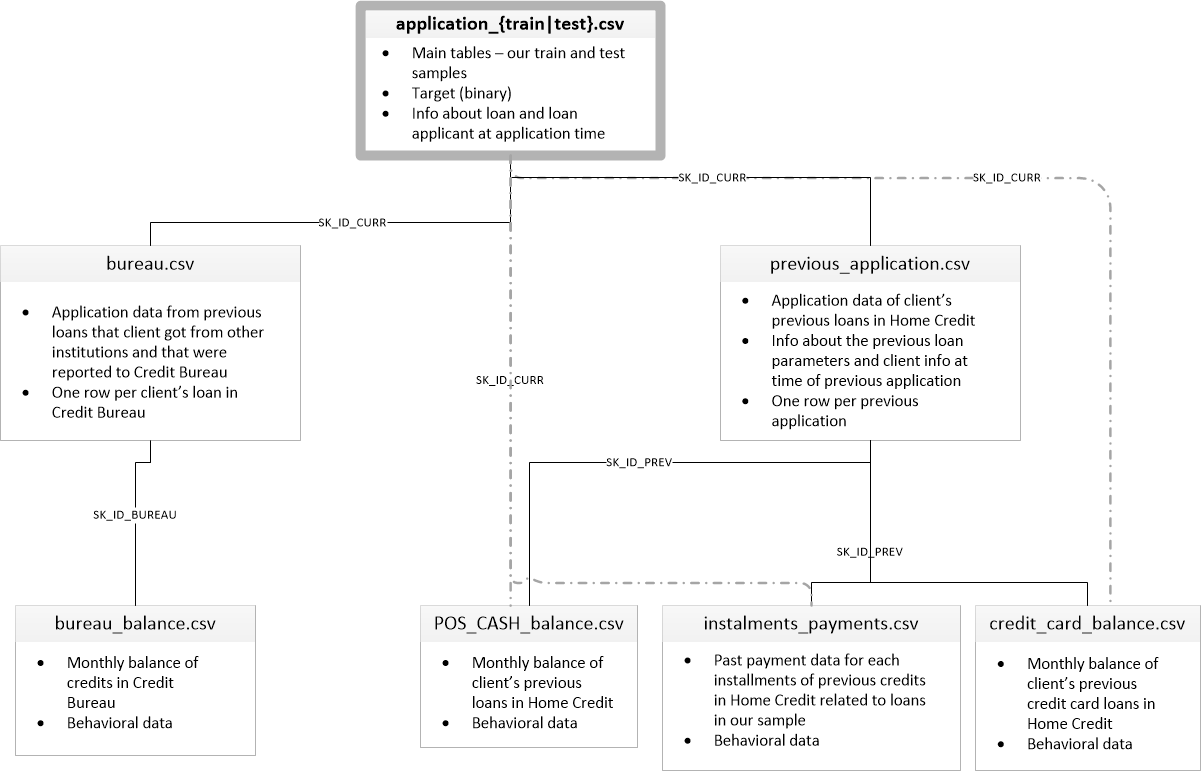


Il y a 8 fichiers.

application_train/test : fichier principal contenant les différents prêts.  
previous_application contient les prêts précédents à home credit.  
pos_cash_balance : données mensuelles des points de vente ou les prêts en espèce précédents avec home credit.  
credit_card_balance : données mensuelles sur les cartes de crédit précédentes avec home credit.  
installments_payment : historique des paiements des précédents prêts avec home credit.  
bureau : contient les données de crédits antérieurs d'autres institutions financières.  
bureau_balance : données mensuelles des crédits de bureau.  

### 2.2 - Chargement des données <a class="anchor" id="section_2_2"></a>

In [251]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn')

In [252]:
data_path = "./data/"
application_train = pd.read_csv(data_path + "application_train.csv", low_memory=False)
application_test = pd.read_csv(data_path + "application_test.csv", low_memory=False)
bureau = pd.read_csv(data_path + 'bureau.csv', low_memory=False)
bureau_balance = pd.read_csv(data_path + 'bureau_balance.csv', low_memory=False)
previous_application = pd.read_csv(data_path + 'previous_application.csv', low_memory=False)
credit_card = pd.read_csv(data_path + 'credit_card_balance.csv', low_memory=False)
insta_payments = pd.read_csv(data_path + 'installments_payments.csv', low_memory=False)
pos_cash = pd.read_csv(data_path + 'POS_CASH_balance.csv', low_memory=False)


### 2.3 - Aperçu des entêtes <a class="anchor" id="section_2_3"></a>

In [253]:
application_train.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [254]:
application_test.head()

,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100001,Cash loans,F,N,Y,0,135000.0,568800.0,20560.5,450000.0,Unaccompanied,Working,Higher education,Married,House / apartment,0.018850,-19241,-2329,-5170.0,-812,NaN,1,1,0,1,0,1,NaN,2.0,2,2,TUESDAY,18,0,0,0,0,0,0,Kindergarten,0.752614,0.789654,0.159520,0.0660,0.0590,0.9732,NaN,NaN,NaN,0.1379,0.125,NaN,NaN,NaN,0.0505,NaN,NaN,0.0672,0.0612,0.9732,NaN,NaN,NaN,0.1379,0.125,NaN,NaN,NaN,0.0526,NaN,NaN,0.0666,0.0590,0.9732,NaN,NaN,NaN,0.1379,0.125,NaN,NaN,NaN,0.0514,NaN,NaN,NaN,block of flats,0.0392,"Stone, brick",No,0.0,0.0,0.0,0.0,-1740.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
1,100005,Cash loans,M,N,Y,0,99000.0,222768.0,17370.0,180000.0,Unaccompanied,Working,Secondary / secondary special,Married,House / apartment,0.035792,-18064,-4469,-9118.0,-1623,NaN,1,1,0,1,0,0,Low-skill Laborers,2.0,2,2,FRIDAY,9,0,0,0,0,0,0,Self-employed,0.564990,0.291656,0.432962,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
2,100013,Cash loans,M,Y,Y,0,202500.0,663264.0,69777.0,630000.0,NaN,Working,Higher education,Married,House / apartment,0.019101,-20038,-4458,-2175.0,-3503,5.0,1,1,0,1,0,0,Drivers,2.0,2,2,MONDAY,14,0,0,0,0,0,0,Transport: type 3,NaN,0.699787,0.610991,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,-856.0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,1.0,4.0
3,100028,Cash loans,F,N,Y,2,315000.0,1575000.0,49018.5,1575000.0,Unaccompanied,Working,Secondary / secondary special,Married

In [255]:
bureau.head()

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


In [256]:
bureau_balance.head()

,SK_ID_BUREAU,MONTHS_BALANCE,STATUS
0,5715448,0,C
1,5715448,-1,C
2,5715448,-2,C
3,5715448,-3,C
4,5715448,-4,C


In [257]:
previous_application.head()

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,FLAG_LAST_APPL_PER_CONTRACT,NFLAG_LAST_APPL_IN_DAY,RATE_DOWN_PAYMENT,RATE_INTEREST_PRIMARY,RATE_INTEREST_PRIVILEGED,NAME_CASH_LOAN_PURPOSE,NAME_CONTRACT_STATUS,DAYS_DECISION,NAME_PAYMENT_TYPE,CODE_REJECT_REASON,NAME_TYPE_SUITE,NAME_CLIENT_TYPE,NAME_GOODS_CATEGORY,NAME_PORTFOLIO,NAME_PRODUCT_TYPE,CHANNEL_TYPE,SELLERPLACE_AREA,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,Y,1,0.0,0.182832,0.867336,XAP,Approved,-73,Cash through the bank,XAP,NaN,Repeater,Mobile,POS,XNA,Country-wide,35,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,Y,1,NaN,NaN,NaN,XNA,Approved,-164,XNA,XAP,Unaccompanied,Repeater,XNA,Cash,x-sell,Contact center,-1,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,Y,1,NaN,NaN,NaN,XNA,Approved,-301,Cash through the bank,XAP,"Spouse, partner",Repeater,XNA,Cash,x-sell,Credit and cash offices,-1,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,Y,1,NaN,NaN,NaN,XNA,Approved,-512,Cash through the bank,XAP,NaN,Repeater,XNA,Cash,x-sell,Credit and cash offices,-1,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,Y,1,NaN,NaN,NaN,Repairs,Refused,-781,Cash through the bank,HC,NaN,Repeater,XNA,Cash,walk-in,Credit and cash offices,-1,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


In [258]:
credit_card.head()

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,AMT_PAYMENT_CURRENT,AMT_PAYMENT_TOTAL_CURRENT,AMT_RECEIVABLE_PRINCIPAL,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,CNT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_POS_CURRENT,CNT_INSTALMENT_MATURE_CUM,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,2562384,378907,-6,56.970,135000,0.0,877.5,0.0,877.5,1700.325,1800.0,1800.0,0.000,0.000,0.000,0.0,1,0.0,1.0,35.0,Active,0,0
1,2582071,363914,-1,63975.555,45000,2250.0,2250.0,0.0,0.0,2250.000,2250.0,2250.0,60175.080,64875.555,64875.555,1.0,1,0.0,0.0,69.0,Active,0,0
2,1740877,371185,-7,31815.225,450000,0.0,0.0,0.0,0.0,2250.000,2250.0,2250.0,26926.425,31460.085,31460.085,0.0,0,0.0,0.0,30.0,Active,0,0
3,1389973,337855,-4,236572.110,225000,2250.0,2250.0,0.0,0.0,11795.760,11925.0,11925.0,224949.285,233048.970,233048.970,1.0,1,0.0,0.0,10.0,Active,0,0
4,1891521,126868,-1,453919.455,450000,0.0,11547.0,0.0,11547.0,22924.890,27000.0,27000.0,443044.395,453919.455,453919.455,0.0,1,0.0,1.0,101.0,Active,0,0


In [259]:
insta_payments.head()

,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
0,1054186,161674,1.0,6,-1180.0,-1187.0,6948.360,6948.360
1,1330831,151639,0.0,34,-2156.0,-2156.0,1716.525,1716.525
2,2085231,193053,2.0,1,-63.0,-63.0,25425.000,25425.000
3,2452527,199697,1.0,3,-2418.0,-2426.0,24350.130,24350.130
4,2714724,167756,1.0,2,-1383.0,-1366.0,2165.040,2160.585


In [260]:
pos_cash.head()

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,CNT_INSTALMENT,CNT_INSTALMENT_FUTURE,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,1803195,182943,-31,48.0,45.0,Active,0,0
1,1715348,367990,-33,36.0,35.0,Active,0,0
2,1784872,397406,-32,12.0,9.0,Active,0,0
3,1903291,269225,-35,48.0,42.0,Active,0,0
4,2341044,334279,-35,36.0,35.0,Active,0,0



application_train contient la colonne TARGET, application_test ne contient pas cette colonne.  
0 : prêt remboursé  
1 : prêt non remboursé  

### 2.4 - Dimensions <a class="anchor" id="section_2_4"></a>

In [261]:
def print_dataframe_shape(df,df_name):
    print(f'{df_name} comporte {df.shape[0]} lignes et {df.shape[1]} colonnes' )


In [262]:
print_dataframe_shape(application_train,'application_train')
print_dataframe_shape(application_test,'application_test')
print_dataframe_shape(bureau,'bureau')
print_dataframe_shape(bureau_balance,'bureau_balance')
print_dataframe_shape(previous_application,'previous_application')
print_dataframe_shape(credit_card,'credit_card_balance')
print_dataframe_shape(insta_payments,'installments_payments')
print_dataframe_shape(pos_cash,'POS_CASH_balance')


application_train comporte 307511 lignes et 122 colonnes
application_test comporte 48744 lignes et 121 colonnes
bureau comporte 1716428 lignes et 17 colonnes
bureau_balance comporte 27299925 lignes et 3 colonnes
previous_application comporte 1670214 lignes et 37 colonnes
credit_card_balance comporte 3840312 lignes et 23 colonnes
installments_payments comporte 13605401 lignes et 8 colonnes
POS_CASH_balance comporte 10001358 lignes et 8 colonnes


Ce jeu de données est important. Il comprend de nombreuses lignes et colonnes.  

application_test ne sera pas utilisé dans ce projet car il ne contient pas la colonne TARGET.  
application_train contient de nombreuses lignes, un jeu de test pourra être extrait de application_train.  

In [263]:
del application_test

## 3 - Analyse exploratoire <a class="anchor" id="chapter3"></a>

### 3.1 - Valeurs manquantes <a class="anchor" id="section_3_1"></a>

In [264]:
# retourne le pourcentage de valeurs manquantes pour chaque colonne de la dataframe passée en paramètre
def valeurs_manquantes(df):
    valeurs_manquantes = ((df.isna().sum()/df.shape[0])*100).sort_values(ascending=False)  
    return valeurs_manquantes

# affichage du pourcentage des valeurs manquantes par colonne pour une dataframe donnée ainsi que le seuil choisi
def graph_valeurs_manquantes(df, df_name, seuil_valeurs_manquantes=90):
    df_valeurs_manquantes = table_valeurs_manquantes(df)
    plt.figure(figsize=(30,15))
    sns.barplot(data=df_valeurs_manquantes,x=df_valeurs_manquantes.index,y=df_valeurs_manquantes.columns[0])
    plt.title(f'Pourcentage de valeurs manquantes dans {df_name}', fontsize = 20)
    plt.xticks(rotation = 90)
    plt.axhline(y = seuil_valeurs_manquantes, color ='red')
    plt.grid()
    return plt.show()

# retourne le pourcentage des valeurs manquantes des colonnes d'une dataframe dans une dataframe
def table_valeurs_manquantes(df):
    return pd.DataFrame(valeurs_manquantes(df),columns=['% de valeurs manquantes'])


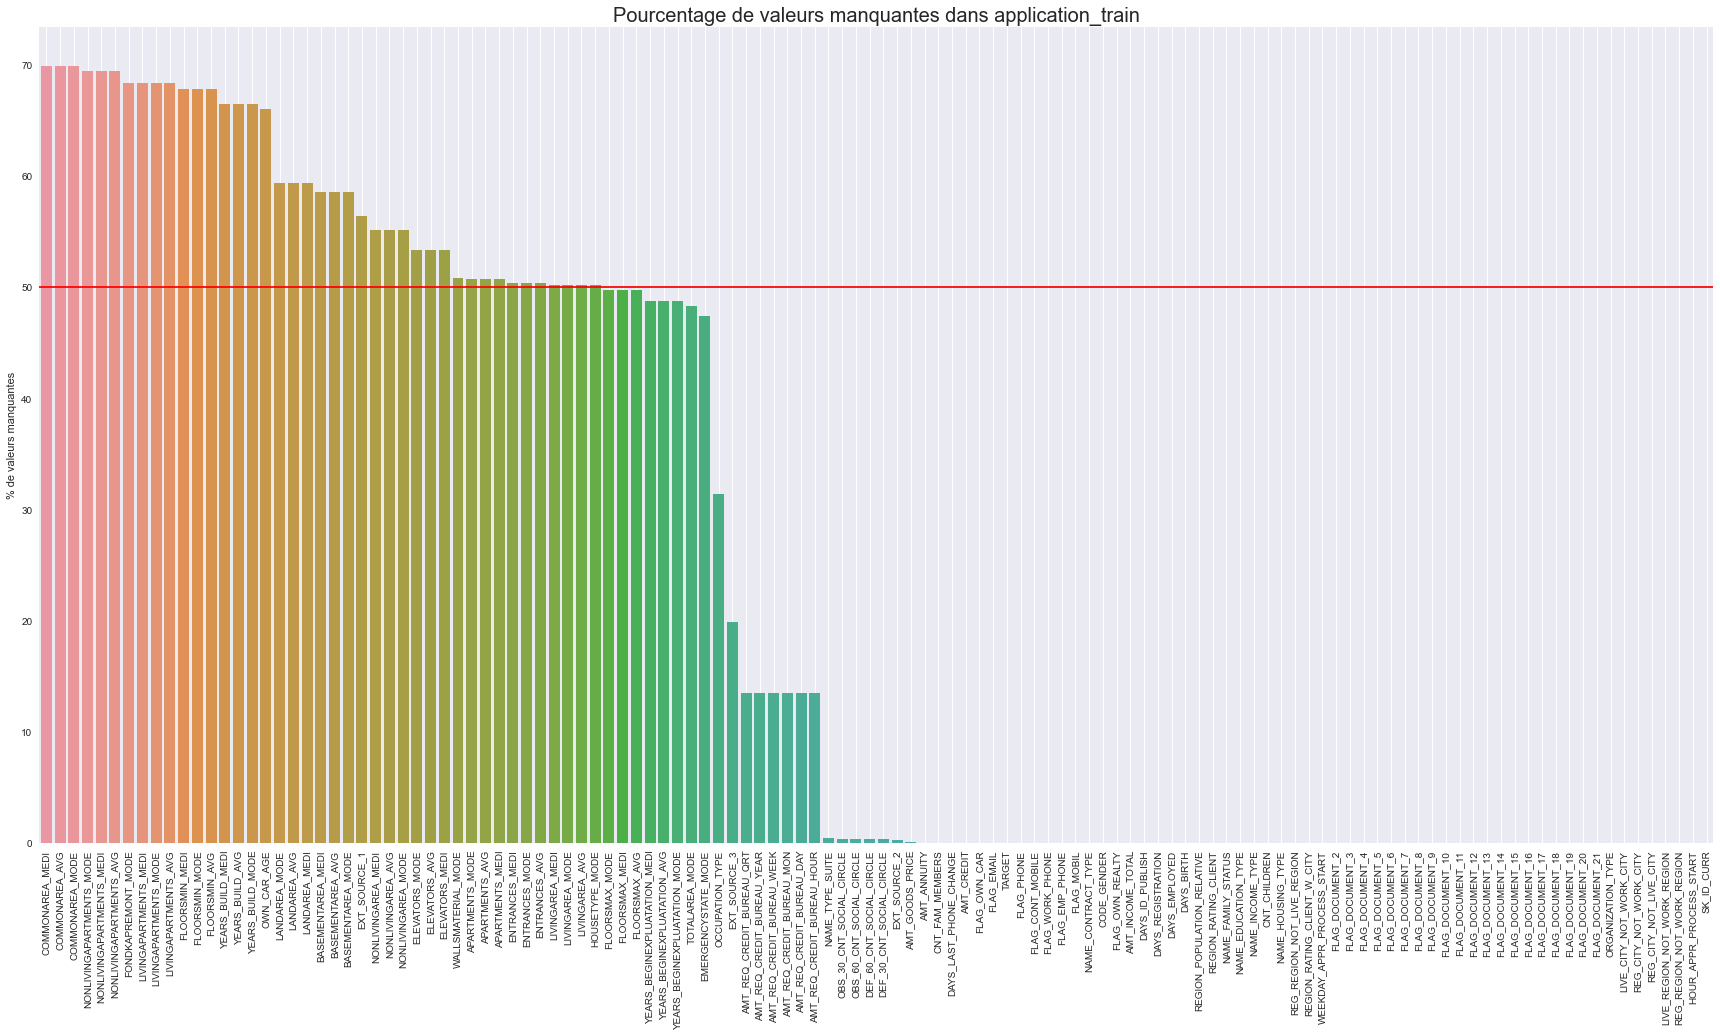

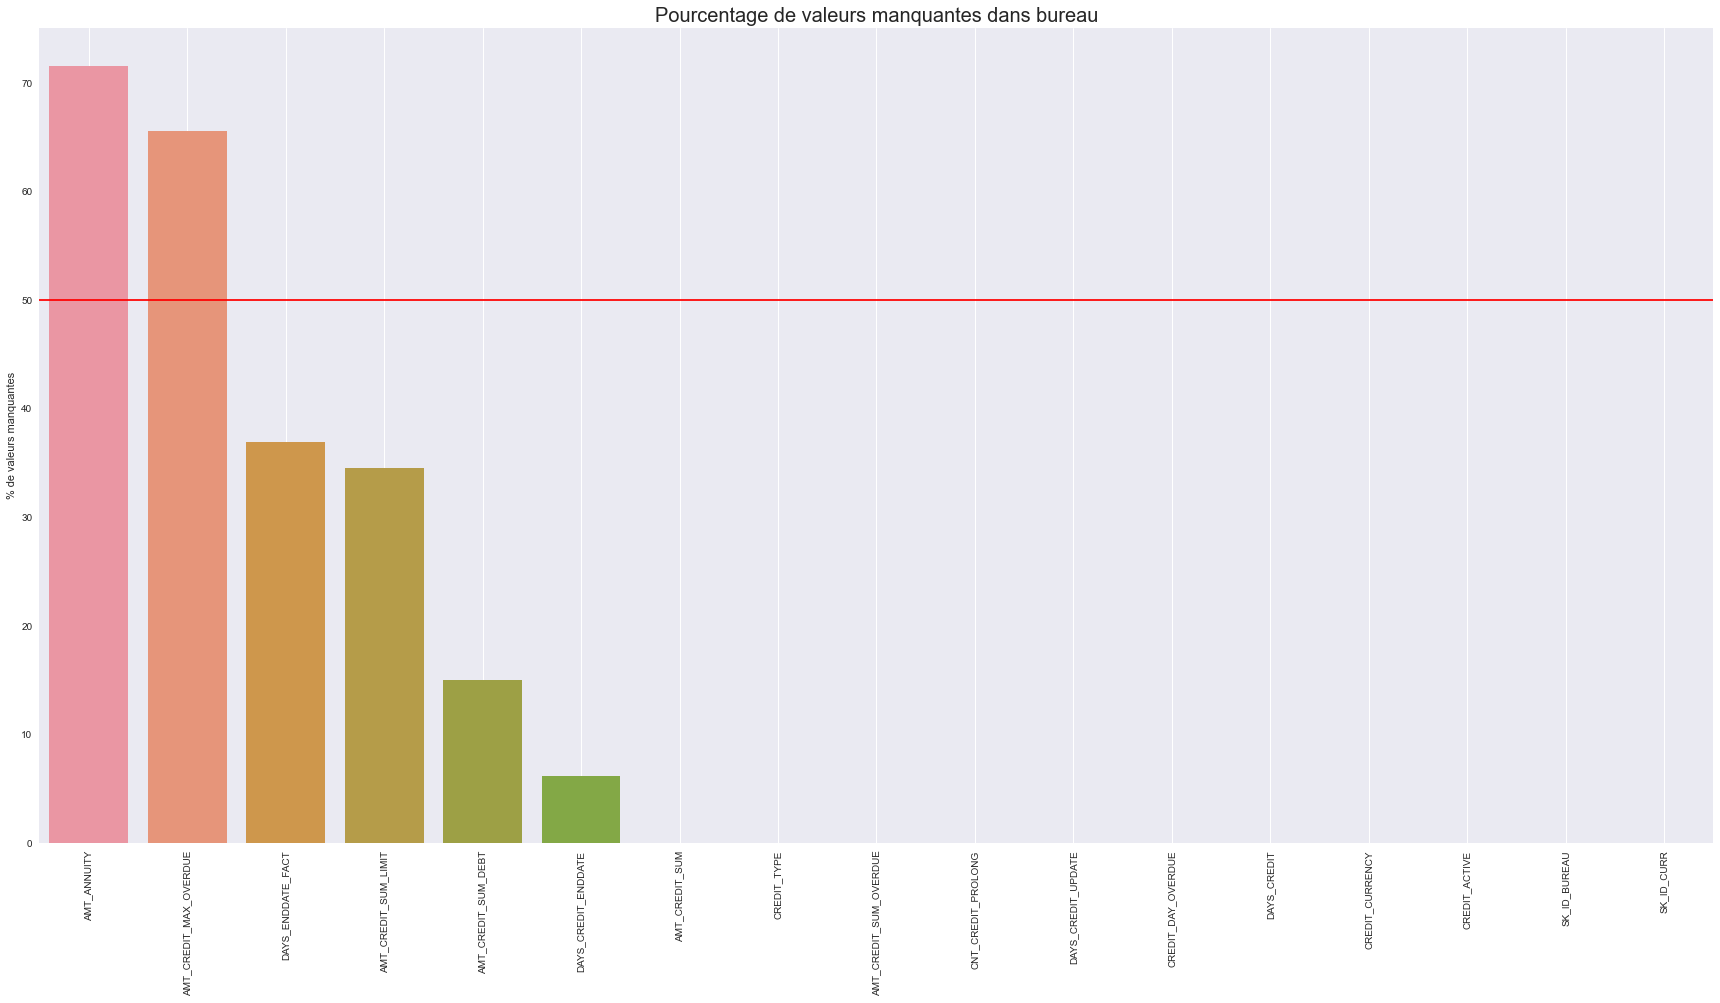

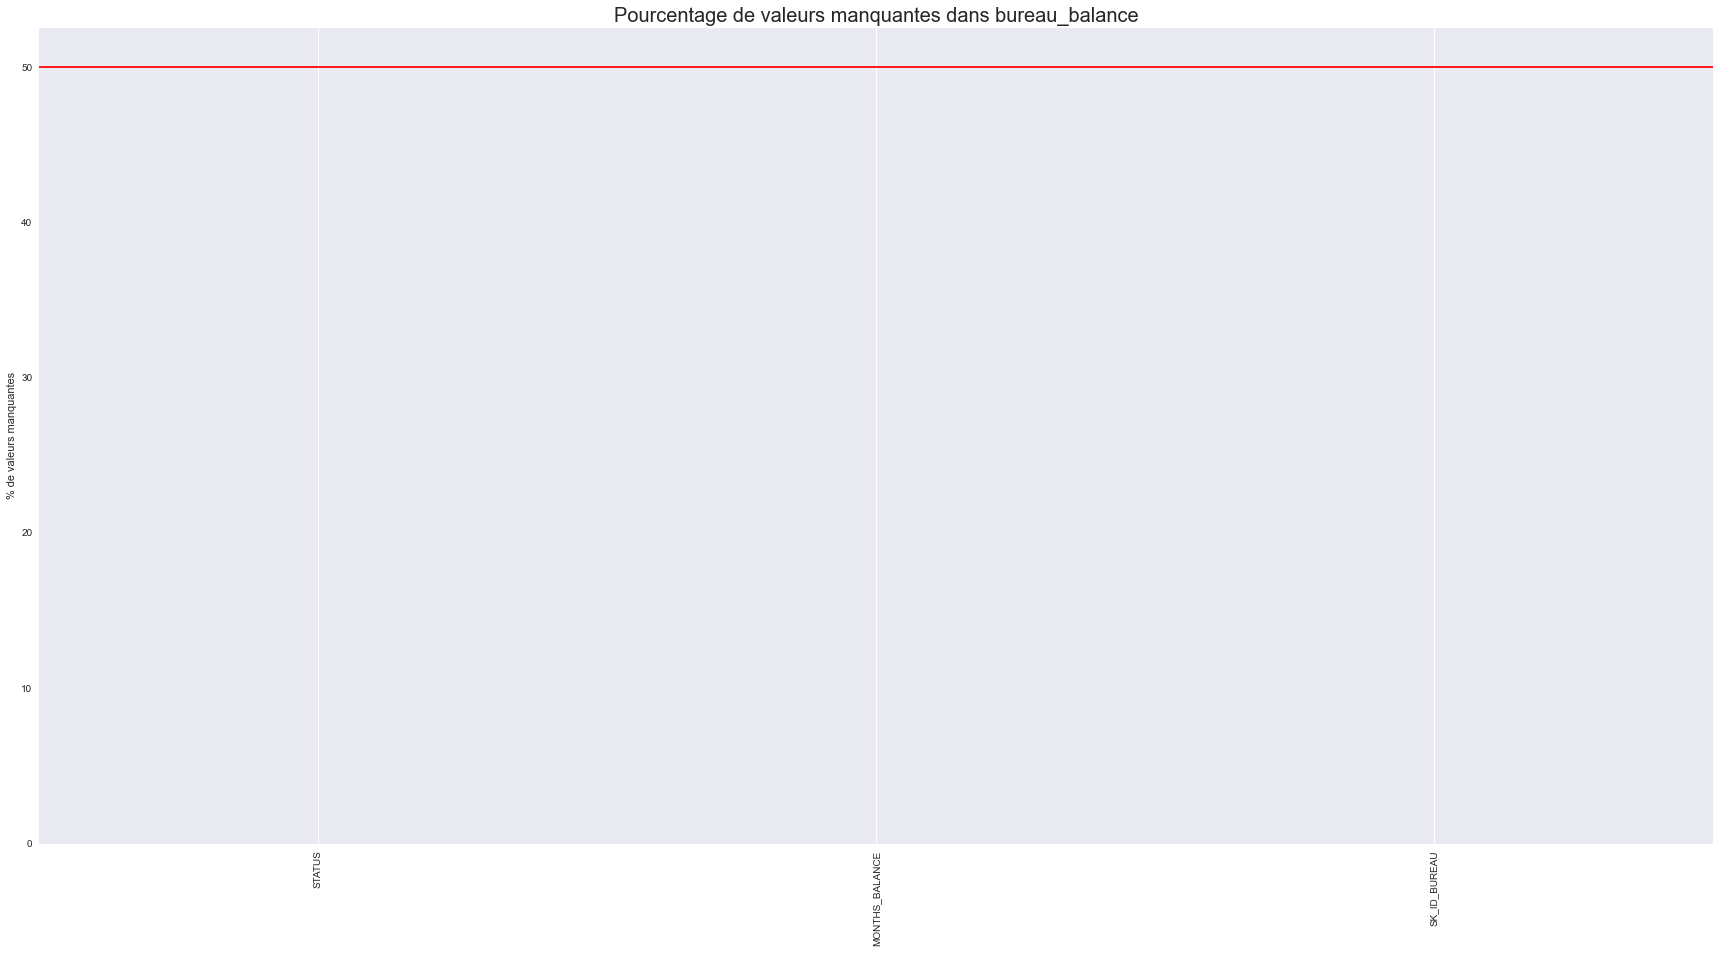

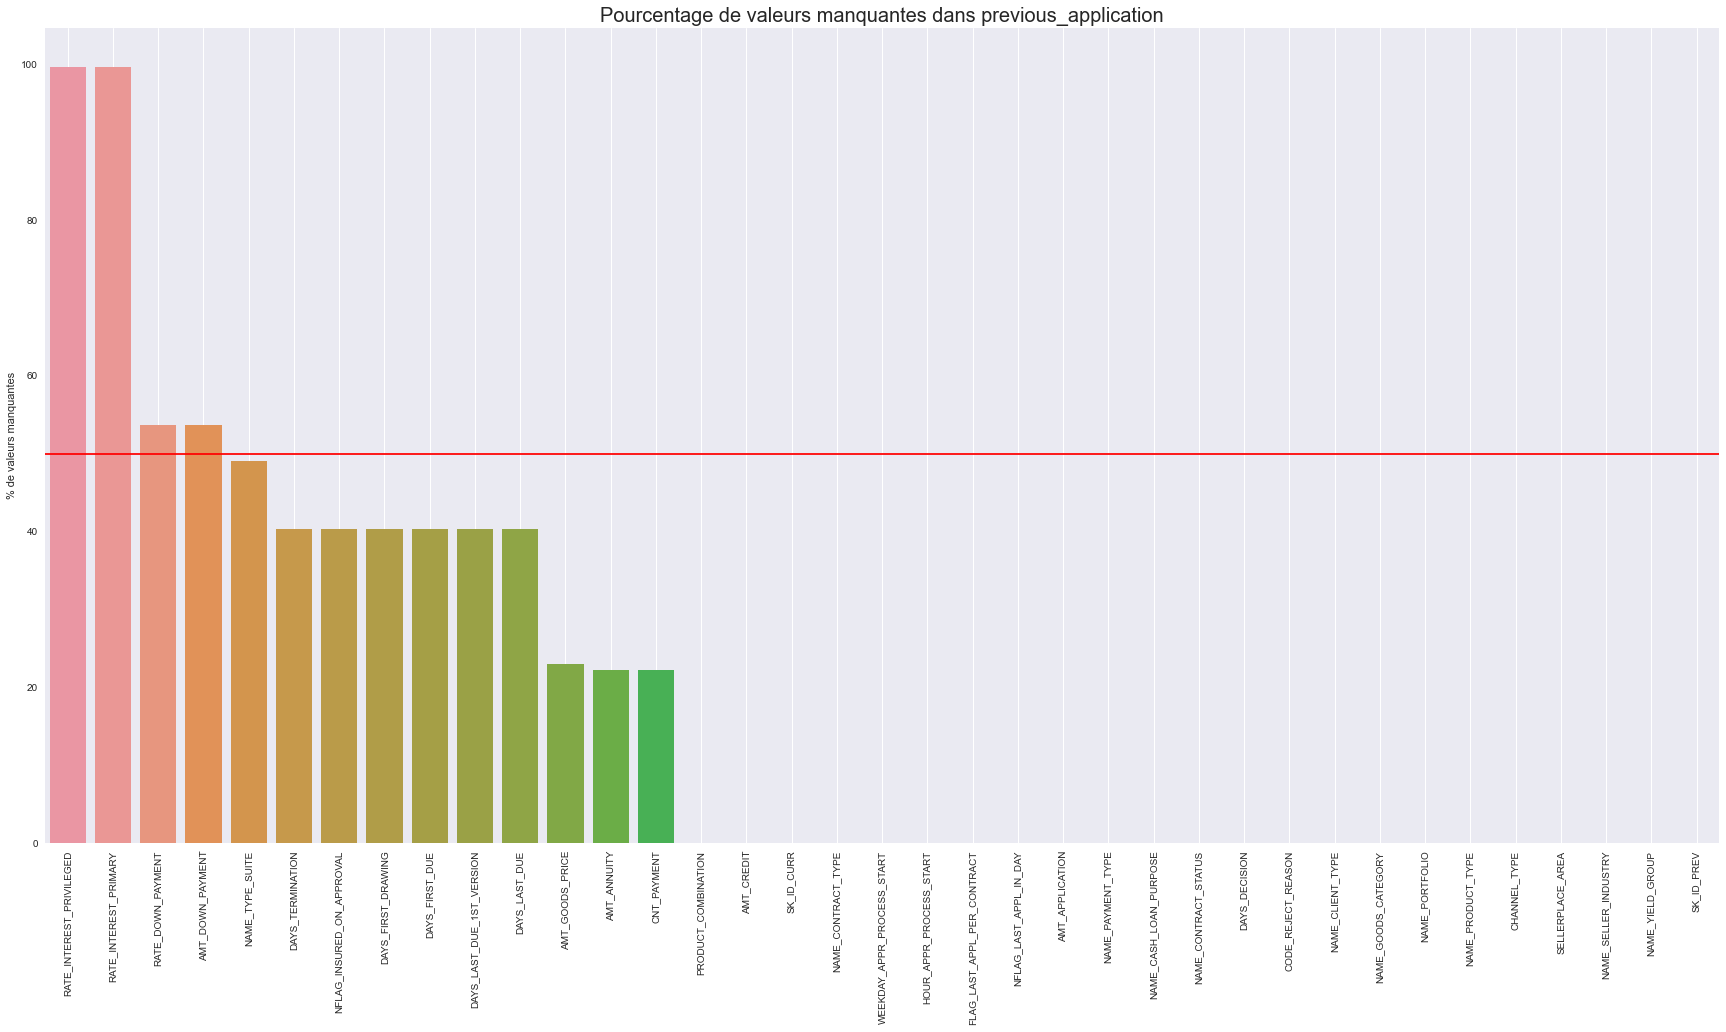

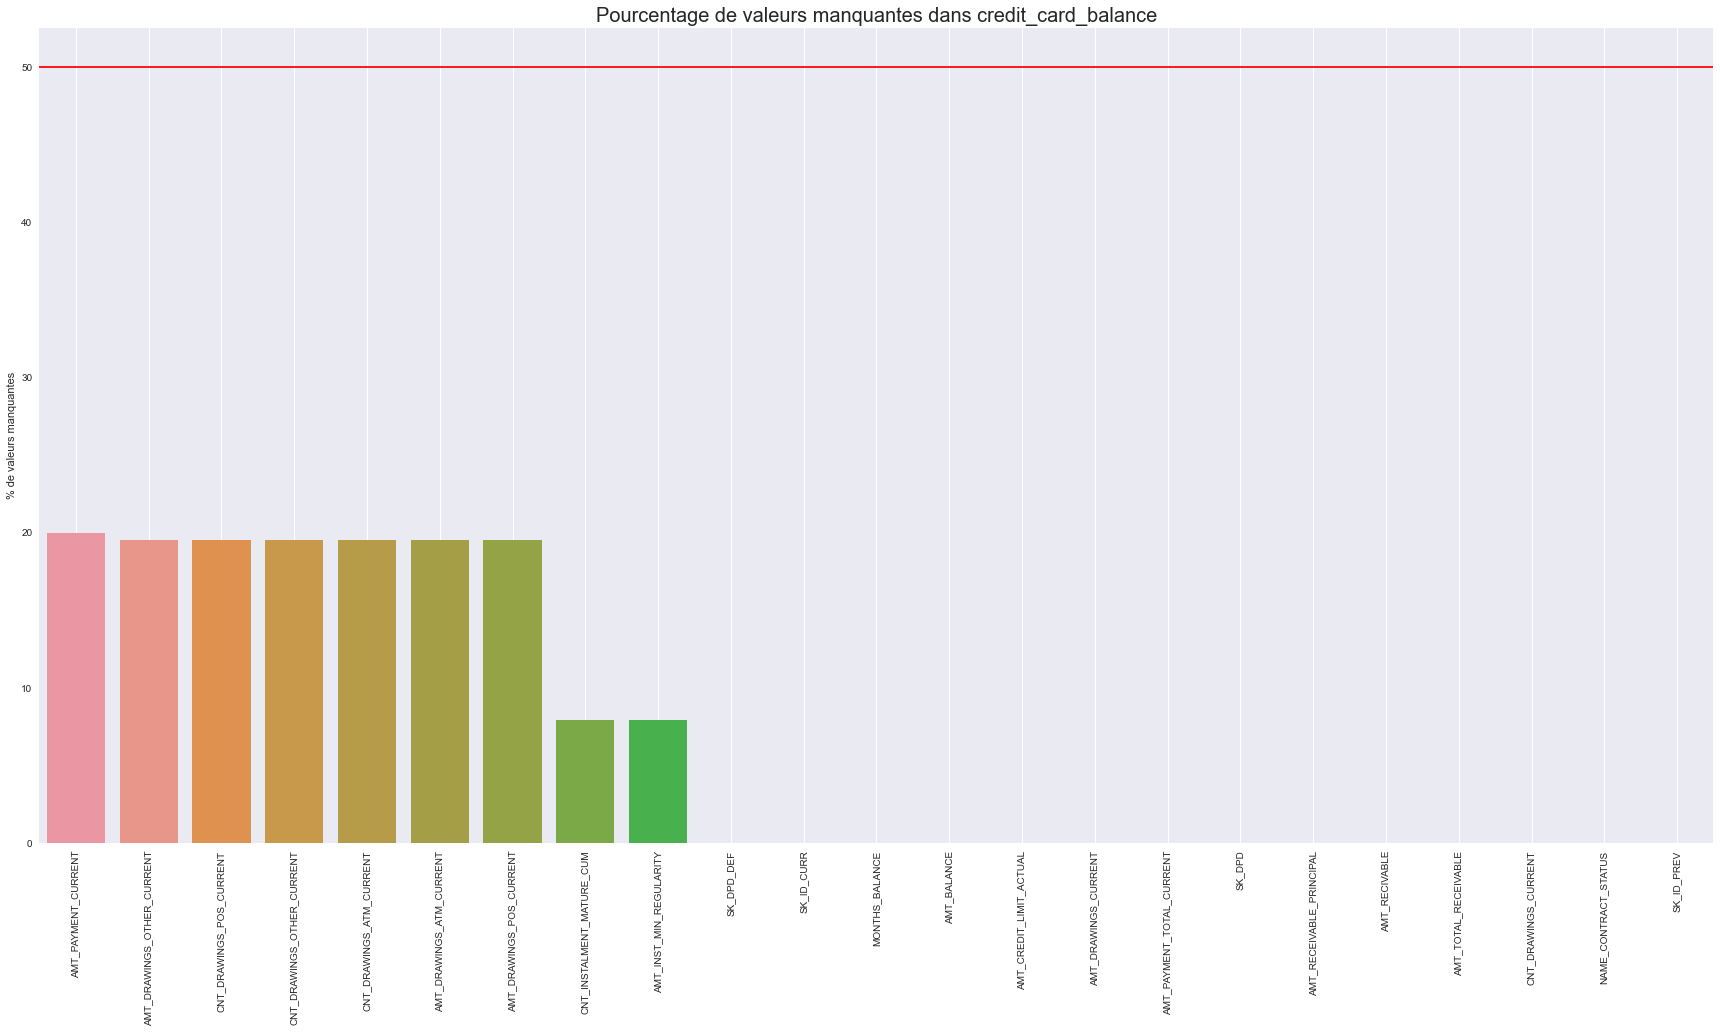

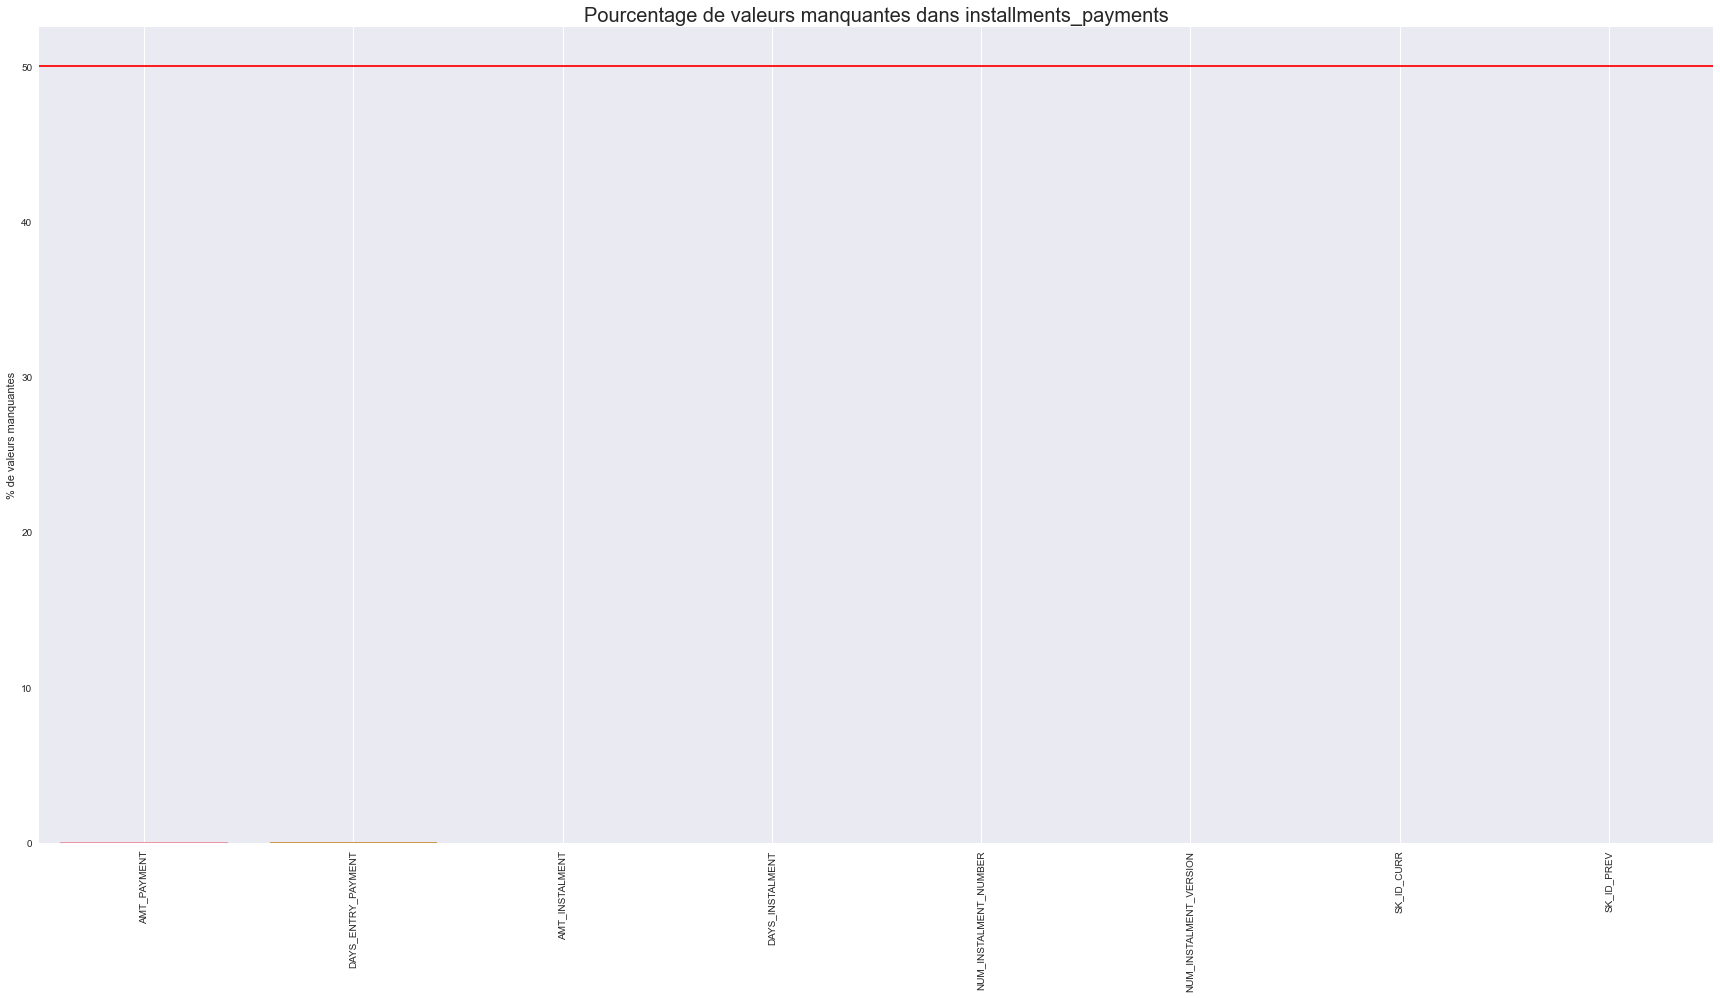

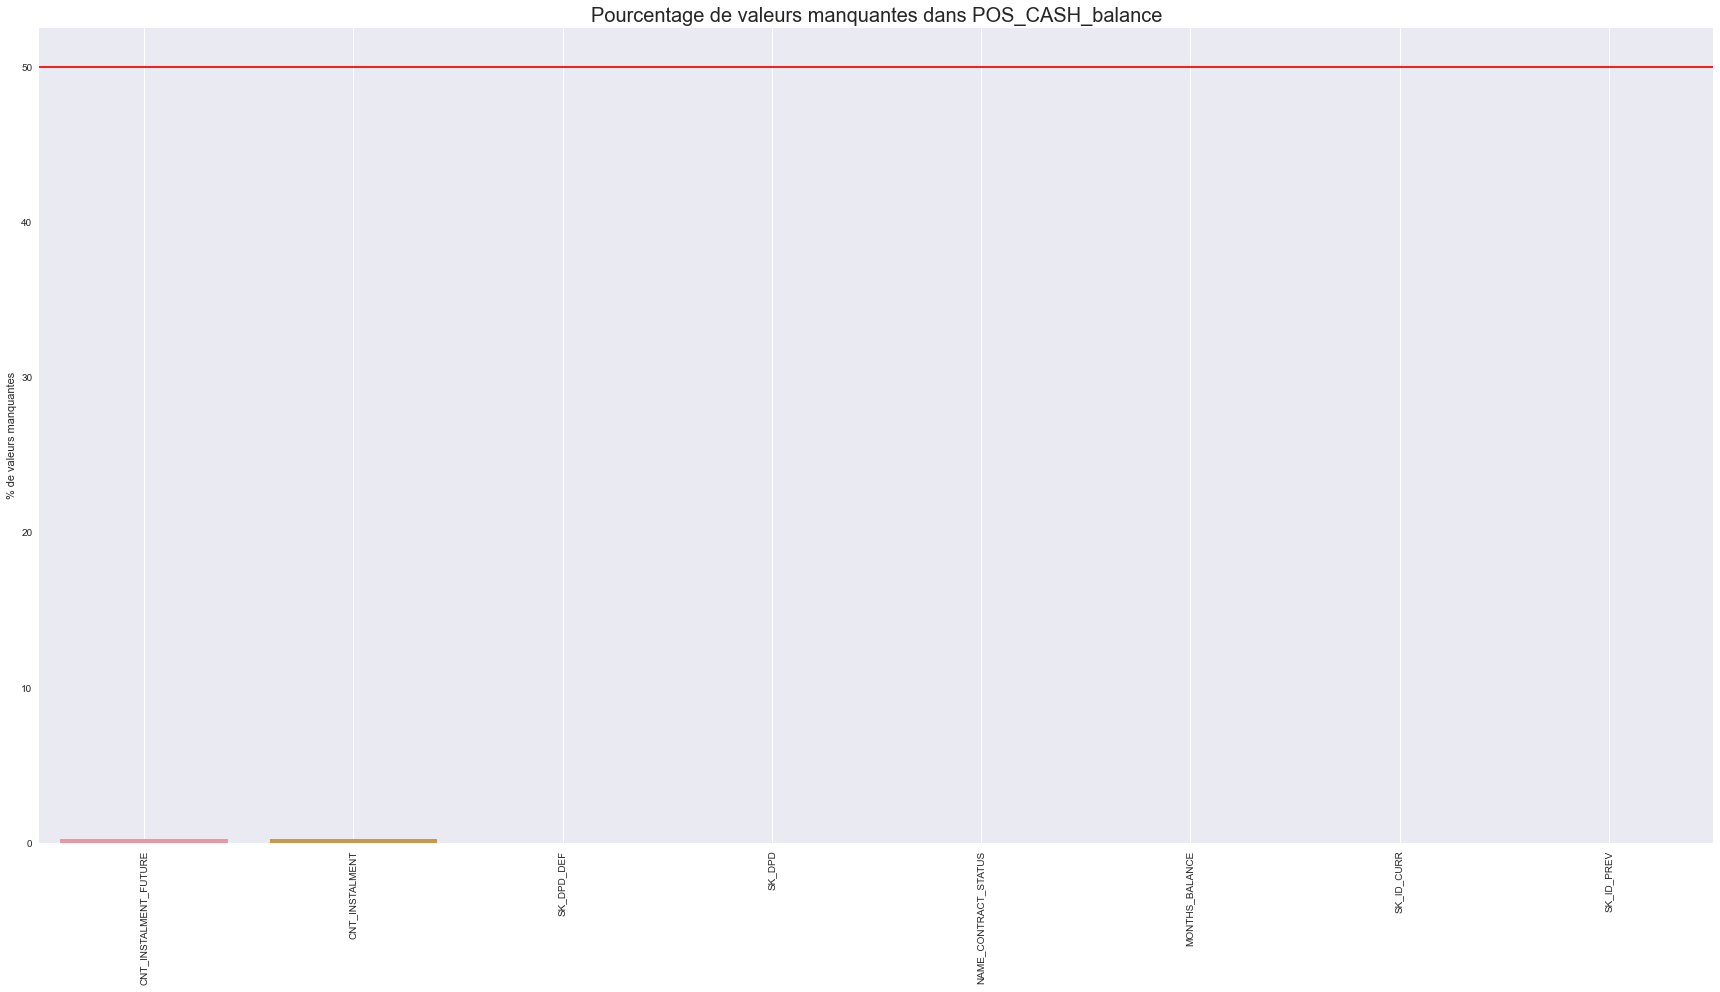

In [265]:
graph_valeurs_manquantes(application_train, 'application_train', 50)
graph_valeurs_manquantes(bureau, 'bureau', 50)
graph_valeurs_manquantes(bureau_balance, 'bureau_balance', 50)
graph_valeurs_manquantes(previous_application, 'previous_application', 50)
graph_valeurs_manquantes(credit_card, 'credit_card_balance', 50)
graph_valeurs_manquantes(insta_payments, 'installments_payments', 50)
graph_valeurs_manquantes(pos_cash, 'POS_CASH_balance', 50)


Il y a de nombreuses valeurs manquantes.  
Pour la plupart des variables, le pourcentage ne dépasse pas 70% environ de valeurs manquantes.  
Les données de ces variables peuvent être utiles pour la prédiction, ces colonnes seront gardées.  
Pour la plupart des algorithmes de machine learning, il ne doit pas y avoir de valeurs manquantes.  
Elles seront donc à traiter.  

previous_application contient deux colonnes avec presque 100% de valeurs manquantes: 

In [266]:
table_valeurs_manquantes(previous_application).head()

,% de valeurs manquantes
RATE_INTEREST_PRIVILEGED,99.643698
RATE_INTEREST_PRIMARY,99.643698
RATE_DOWN_PAYMENT,53.636480
AMT_DOWN_PAYMENT,53.636480
NAME_TYPE_SUITE,49.119754


Les deux colonnes avec plus de 99% de valeurs manquantes seront supprimées.

### 3.2 - Doublons <a class="anchor" id="section_3_2"></a>

In [267]:

def analyse_doublons(df_doublons, df, df_name,key):

    duplicate_key = get_true_value(df.duplicated(subset=key).value_counts())
    duplicate_all = get_true_value(df.duplicated().value_counts())
    
    # pas de clé pour l'historique des paiements
    if (df_name == 'installments_payments'):
        duplicate_key = 'N/A'
    
    df_doublons = df_doublons.append({'dataframe':df_name, 
                                          'key' : duplicate_key, 
                                          'all' : duplicate_all},
                                         ignore_index=True)
    return df_doublons


def get_true_value(value_counts):
    true_value_nb = 0
    for idx,name in enumerate(value_counts.index.tolist()):
        if (name is True):
            true_value_nb = value_counts[idx]  
    return true_value_nb


In [268]:
df_doublons = pd.DataFrame(columns=['dataframe','key','all'])

df_doublons = analyse_doublons(df_doublons,application_train,'application_train',['SK_ID_CURR'])
df_doublons = analyse_doublons(df_doublons,bureau,'bureau',['SK_ID_BUREAU'])
df_doublons = analyse_doublons(df_doublons,bureau_balance,'bureau_balance',['SK_ID_BUREAU','MONTHS_BALANCE'])
df_doublons = analyse_doublons(df_doublons,previous_application,'previous_application','SK_ID_PREV')
df_doublons = analyse_doublons(df_doublons,credit_card,'credit_card_balance',['SK_ID_PREV','MONTHS_BALANCE'])
df_doublons = analyse_doublons(df_doublons,insta_payments,'installments_payments','SK_ID_PREV')
df_doublons = analyse_doublons(df_doublons,pos_cash,'POS_CASH_balance',['SK_ID_PREV','MONTHS_BALANCE'])

df_doublons

,dataframe,key,all
0,application_train,0,0
1,bureau,0,0
2,bureau_balance,0,0
3,previous_application,0,0
4,credit_card_balance,0,0
5,installments_payments,N/A,0
6,POS_CASH_balance,0,0


Il n'y a aucune ligne entièrement dupliquée (colonne all).  
Les clés sont uniques.  
Il n'y a pas de clé pour l'historique des paiements.  


### 3.3 - Types de données <a class="anchor" id="section_3_3"></a>

In [269]:
def binary_cols(df):
    return [col for col in df if np.isin(df[col].unique(), [0, 1]).all()]

def integer_cols(df):
    binary_cols_list = binary_cols(df)
    return [col for col in df if col not in binary_cols_list and df[col].dtype == 'int64']

def float_cols(df):
    return [col for col in df if df[col].dtype == 'float64']

def object_cols(df):
    return [col for col in df if df[col].dtype == 'object']

def df_types_len(df):
    int_cols_len = len(integer_cols(df))
    float_cols_len = len(float_cols(df))
    binary_cols_len = len(binary_cols(df))
    object_cols_len = len(object_cols(df))
    return {'int' : int_cols_len, 'float' : float_cols_len, 'binary' : binary_cols_len, 'object' : object_cols_len}

def add_df_types_line(df_types,df,df_name):
    df_types_len_dict = df_types_len(df)
    return df_types.append({'df' : df_name,
                            'int' : df_types_len_dict['int'],
                            'float' : df_types_len_dict['float'] , 
                            'binary' : df_types_len_dict['binary'] , 
                            'object' : df_types_len_dict['object']} , 
                           ignore_index=True)


In [270]:
df_types = pd.DataFrame(columns=['df','int','float','binary','object'])

df_types = add_df_types_line(df_types,application_train,'application_train')
df_types = add_df_types_line(df_types,bureau,'bureau')
df_types = add_df_types_line(df_types,bureau_balance,'bureau_balance')
df_types = add_df_types_line(df_types,previous_application,'previous_application')
df_types = add_df_types_line(df_types,credit_card,'credit_card_balance')
df_types = add_df_types_line(df_types,insta_payments,'installments_payments')
df_types = add_df_types_line(df_types,pos_cash,'POS_CASH_balance')

df_types


,df,int,float,binary,object
0,application_train,8,65,33,16
1,bureau,6,8,0,3
2,bureau_balance,2,0,0,1
3,previous_application,5,15,1,16
4,credit_card_balance,7,15,0,1
5,installments_payments,3,5,0,0
6,POS_CASH_balance,5,2,0,1


Plusieurs variables sont des variables catégoriques (object).  
La plupart des algorithmes de machine learning nécessitent des variables numériques.  
Ces variables catégoriques seront à traiter.  

### 3.4 - Statistiques <a class="anchor" id="section_3_4"></a>

In [271]:

pd.set_option('display.max_columns', None)

def add_days_vars(df_days_vars, df, df_name,year_transform = False):
    divisor = 1
    unit=''
    if (year_transform):
        divisor = 365
        unit = ' (années)'
    for col in np.concatenate((integer_cols(df),float_cols(df))):
        if col.split("_")[0] == 'DAYS':
            min = df[col].min()/divisor
            max = df[col].max()/divisor
            df_types_len_dict = df_types_len(df)
            df_days_vars= df_days_vars.append({
                                    'dataframe' : df_name,
                                    'var' : col,
                                    'min' + unit : min,
                                    'max' + unit : max } , 
                                   ignore_index=True)
    return df_days_vars

Statistiques du dataset application_train :

In [272]:
application_train.describe()


,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,TOTALAREA_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,104582.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307509.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,134133.000000,3.068510e+05,246546.000000,151450.00000,127568.000000,157504.000000,103023.000000,92646.000000,143620.000000,152683.000000,154491.000000,98869.000000,124921.000000,97312.000000,153161.000000,93997.000000,137829.000000,151450.000000,127568.000000,157504.000000,103023.000000,92646.000000,143620.000000,152683.000000,154491.000000,98869.000000,124921.000000,97312.000000,153161.000000,93997.000000,137829.000000,151450.000000,127568.000000,157504.000000,103023.000000,92646.000000,143620.000000,152683.000000,154491.000000,98869.000000,124921.000000,97312.000000,153161.000000,93997.000000,137829.000000,159080.000000,306490.000000,306490.000000,306490.000000,306490.000000,307510.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.00000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,-4986.120328,-2994.202373,12.061091,0.999997,0.819889,0.199368,0.998133,0.281066,0.056720,2.152665,2.052463,2.031521,12.063419,0.015144,0.050769,0.040659,0.078173,0.230454,0.179555,0.502130,5.143927e-01,0.510853,0.11744,0.088442,0.977735,0.752471,0.044621,0.078942,0.149725,0.226282,0.231894,0.066333,0.100775,0.107399,0.008809,0.028358,0.114231,0.087543,0.977065,0.759637,0.042553,0.074490,0.145193,0.222315,0.228058,0.064958,0.105645,0.105975,0.008076,0.027022,0.117850,0.087955,0.97

In [273]:
max_val = application_train['DAYS_EMPLOYED'].max()
print(f'La valeur max de DAYS_EMPLOYED est de {max_val} jours, ce qui représente environ {round(max_val/365)} années.')


La valeur max de DAYS_EMPLOYED est de 365243 jours, ce qui représente environ 1001 années.


La colonne DAYS_EMPLOYED contient des valeurs aberrantes.  
Vérification si les autres variables relatives à des jours contiennent aussi des valeurs aberrantes.

In [274]:
df_days_vars = pd.DataFrame(columns=['dataframe','var','min','max'])

df_days_vars = add_days_vars(df_days_vars, application_train, 'application_train')
df_days_vars = add_days_vars(df_days_vars, bureau, 'bureau')
df_days_vars = add_days_vars(df_days_vars, bureau_balance, 'bureau_balance')
df_days_vars = add_days_vars(df_days_vars, previous_application, 'previous_application')
df_days_vars = add_days_vars(df_days_vars, credit_card, 'credit_card_balance')
df_days_vars = add_days_vars(df_days_vars, insta_payments, 'installments_payments')
df_days_vars = add_days_vars(df_days_vars, pos_cash, 'POS_CASH_balance')

df_days_vars

,dataframe,var,min,max
0,application_train,DAYS_BIRTH,-25229.0,-7489.0
1,application_train,DAYS_EMPLOYED,-17912.0,365243.0
2,application_train,DAYS_ID_PUBLISH,-7197.0,0.0
3,application_train,DAYS_REGISTRATION,-24672.0,0.0
4,application_train,DAYS_LAST_PHONE_CHANGE,-4292.0,0.0
5,bureau,DAYS_CREDIT,-2922.0,0.0
6,bureau,DAYS_CREDIT_UPDATE,-41947.0,372.0
7,bureau,DAYS_CREDIT_ENDDATE,-42060.0,31199.0
8,bureau,DAYS_ENDDATE_FACT,-42023.0,0.0
9,previous_application,DAYS_DECISION,-2922.0,-1.0


D'autres colonnes contiennent des valeurs aberrantes.  
Pour le voir de façon plus évidente, affichage de ces valeurs en années:

In [275]:
unit = ' (années)'
df_days_vars = pd.DataFrame(columns=['dataframe','var','min' + unit,'max' + unit])

df_days_vars = add_days_vars(df_days_vars, application_train, 'application_train',year_transform=True)
df_days_vars = add_days_vars(df_days_vars, bureau, 'bureau',year_transform=True)
df_days_vars = add_days_vars(df_days_vars, bureau_balance, 'bureau_balance',year_transform=True)
df_days_vars = add_days_vars(df_days_vars, previous_application, 'previous_application',year_transform=True)
df_days_vars = add_days_vars(df_days_vars, credit_card, 'credit_card_balance',year_transform=True)
df_days_vars = add_days_vars(df_days_vars, insta_payments, 'installments_payments',year_transform=True)
df_days_vars = add_days_vars(df_days_vars, pos_cash, 'POS_CASH_balance',year_transform=True)

df_days_vars

,dataframe,var,min (années),max (années)
0,application_train,DAYS_BIRTH,-69.120548,-20.517808
1,application_train,DAYS_EMPLOYED,-49.073973,1000.665753
2,application_train,DAYS_ID_PUBLISH,-19.717808,0.000000
3,application_train,DAYS_REGISTRATION,-67.594521,0.000000
4,application_train,DAYS_LAST_PHONE_CHANGE,-11.758904,0.000000
5,bureau,DAYS_CREDIT,-8.005479,0.000000
6,bureau,DAYS_CREDIT_UPDATE,-114.923288,1.019178
7,bureau,DAYS_CREDIT_ENDDATE,-115.232877,85.476712
8,bureau,DAYS_ENDDATE_FACT,-115.131507,0.000000
9,previous_application,DAYS_DECISION,-8.005479,-0.002740


On peut considérer toutes les valeurs de ce tableau supérieures à 100 comme aberrantes.

Aperçu de la ditributions de DAYS_EMPLOYED avec et sans ces valeurs aberrantes:

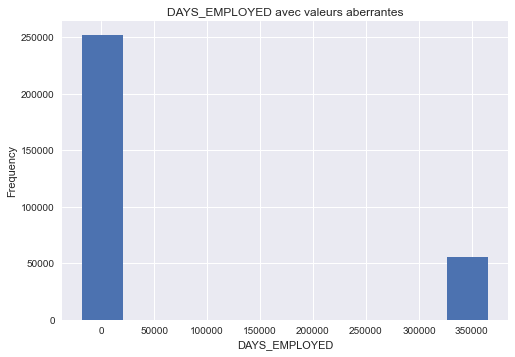

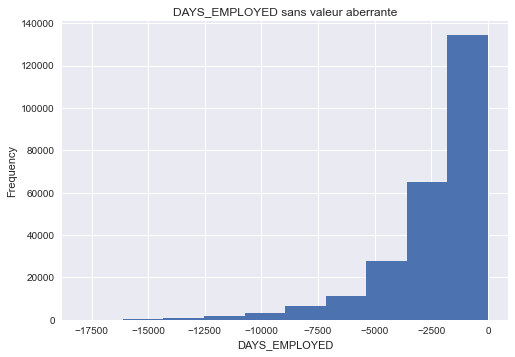

In [276]:
plt.figure()
application_train['DAYS_EMPLOYED'].plot.hist(title = 'DAYS_EMPLOYED avec valeurs aberrantes');
plt.xlabel('DAYS_EMPLOYED');

df_days_employed = application_train.copy()
mask = df_days_employed['DAYS_EMPLOYED']>100*365
df_days_employed[mask]= np.nan

plt.figure()
df_days_employed['DAYS_EMPLOYED'].plot.hist(title = 'DAYS_EMPLOYED sans valeur aberrante');
plt.xlabel('DAYS_EMPLOYED');

del df_days_employed

### 3.5 - Corrélations <a class="anchor" id="section_3_5"></a>

In [277]:
#pd.set_option('display.max_rows', None)

def correlation_main_target():
    return application_train.corr()['TARGET'].sort_values(ascending=True)

def correlation_child_target(df_child):
    df1 =  application_train.copy()
    df2 =  df_child.copy()
    correlation_matrix =  pd.concat([df1.TARGET, df2], axis=1).corr()['TARGET'].sort_values(ascending=False)
    del df1
    del df2
    return correlation_matrix

def print_child_correlations(df, df_name):
    print(f"Corrélation des variables de {df_name} avec la Target :")
    print(correlation_child_target(df))
    print('\n')
    
def print_main_correlations(positive = True, negative = True, absolute = True):
    correlations = correlation_main_target()
    if (positive):
        print('\n')
        print('Corrélations les plus positives:\n', correlations.sort_values(ascending=False).head(10))
    if (negative):
        print('\n')
        print('Corrélations les plus négatives:\n', correlations.sort_values(ascending=True).head(10))
    if (absolute):
        print('\n')
        print('Corrélations absolues:\n', abs(correlations).sort_values(ascending=False).head(10))
        
        
def absolute_main_corr_target_vars(nb_vars):         
    return abs(correlation_main_target()).sort_values(ascending=False).head(nb_vars).index.values
        


Corrélations avec la TARGET des variables de application_train :

In [278]:
print_main_correlations()



Corrélations les plus positives:
 TARGET                         1.000000
DAYS_BIRTH                     0.078239
REGION_RATING_CLIENT_W_CITY    0.060893
REGION_RATING_CLIENT           0.058899
DAYS_LAST_PHONE_CHANGE         0.055218
DAYS_ID_PUBLISH                0.051457
REG_CITY_NOT_WORK_CITY         0.050994
FLAG_EMP_PHONE                 0.045982
REG_CITY_NOT_LIVE_CITY         0.044395
FLAG_DOCUMENT_3                0.044346
Name: TARGET, dtype: float64


Corrélations les plus négatives:
 EXT_SOURCE_3                 -0.178919
EXT_SOURCE_2                 -0.160472
EXT_SOURCE_1                 -0.155317
DAYS_EMPLOYED                -0.044932
FLOORSMAX_AVG                -0.044003
FLOORSMAX_MEDI               -0.043768
FLOORSMAX_MODE               -0.043226
AMT_GOODS_PRICE              -0.039645
REGION_POPULATION_RELATIVE   -0.037227
ELEVATORS_AVG                -0.034199
Name: TARGET, dtype: float64


Corrélations absolues:
 TARGET                         1.000000
EXT_SOURCE_3  

La variable ayant la plus forte corrélation positive avec la TARGET est DAYS_BIRTH.  
Les variables EXT_SOURCE_X sont les variables les plus corrélées négativement avec la TARGET.  
Des analyses bivariées entre ces variables et la TARGET seront effectuées.  



Corrélations avec la TARGET des variables des autres datasets :

In [279]:

print_child_correlations(previous_application, 'previous_application')
print_child_correlations(bureau, 'bureau')
print_child_correlations(bureau_balance, 'bureau_balance')
print_child_correlations(credit_card, 'credit_card_balance')
print_child_correlations(insta_payments, 'installments_payments')
print_child_correlations(pos_cash, 'POS_CASH_balance')



Corrélation des variables de previous_application avec la Target :
TARGET                       1.000000
AMT_DOWN_PAYMENT             0.002496
CNT_PAYMENT                  0.002341
DAYS_LAST_DUE_1ST_VERSION    0.001908
AMT_CREDIT                   0.001833
AMT_APPLICATION              0.001689
AMT_GOODS_PRICE              0.001676
SK_ID_CURR                   0.001107
NFLAG_INSURED_ON_APPROVAL    0.000879
RATE_DOWN_PAYMENT            0.000850
RATE_INTEREST_PRIMARY        0.000542
SK_ID_PREV                   0.000362
DAYS_DECISION               -0.000482
AMT_ANNUITY                 -0.000492
DAYS_FIRST_DUE              -0.000943
SELLERPLACE_AREA            -0.000954
DAYS_TERMINATION            -0.001072
NFLAG_LAST_APPL_IN_DAY      -0.001256
DAYS_FIRST_DRAWING          -0.001293
DAYS_LAST_DUE               -0.001940
HOUR_APPR_PROCESS_START     -0.002285
RATE_INTEREST_PRIVILEGED    -0.026427
Name: TARGET, dtype: float64


Corrélation des variables de bureau avec la Target :
TARGET       

Les corrélations sont beaucoup plus faibles que pour celles de application_train.

Corrélations entre les variables les plus corrélées avec la TARGET :

<AxesSubplot:>

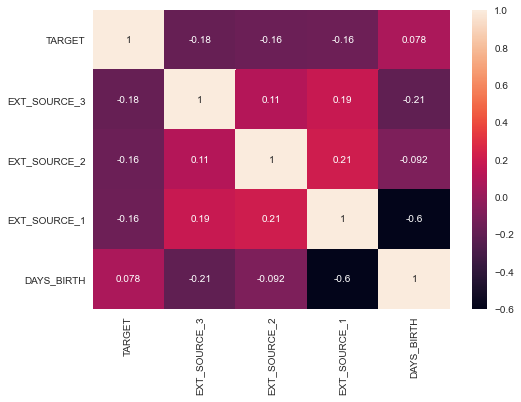

In [280]:
sns.heatmap(application_train[absolute_main_corr_target_vars(5)].corr(),annot = True)


Les variables DAYS_BIRTH et EXT_SOURCE_1 ont le coefficient de corrélation le plus élevé. 
L'âge était probablement un des facteurs pour le score EXT_SOURCE.

### 3.6 - Visualisations <a class="anchor" id="section_3_6"></a>

#### Visualisation de la target

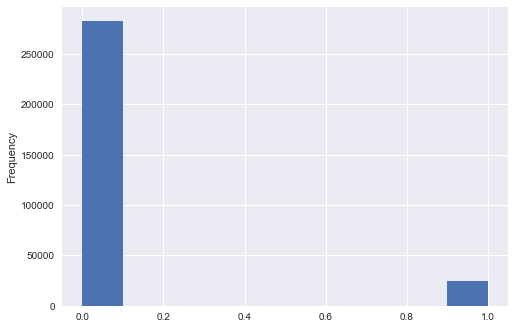

In [281]:
application_train['TARGET'].plot.hist();

Il y a beaucoup plus de valeurs à 0 (pas de défaut de paiement) que de valeurs à 1 (défaut).  
C'est une classification désiquilibrée.  
Ceci sera à prendre en compte pour la modélisation.  


In [282]:
value_counts = application_train['TARGET'].value_counts()
target_0 = (value_counts[0] / application_train.shape[0])*100
target_1 = (value_counts[1] / application_train.shape[0])*100
print(f'Répartition des valeurs de target:\n')
print(f'target 0   : {value_counts[0]} : {target_0} %')
print(f'target 1   : {value_counts[1]}  : {target_1} %')

Répartition des valeurs de target:

target 0   : 282686 : 91.92711805431351 %
target 1   : 24825  : 8.072881945686495 %


#### Visualisation de variables numériques

In [283]:
        
def plot_correl_abs_dist(dist_nb):
    #abolute_main_corr = abs(correlation_main_target()).sort_values(ascending=False).head(dist_nb).index.values
    corr_vars = absolute_main_corr_target_vars(dist_nb)
    
    #numVar = abolute_main_corr.shape[0]
    numVar = corr_vars.shape[0]
    plt.figure(figsize=(15,15))
    #plt.figure()
    for i,var in enumerate(corr_vars):    
        plt.subplot(numVar,3,i+1)
        application_train[var].hist(edgecolor = 'k',)
        plt.title(var, fontsize = 10)
        plt.tight_layout()
    plt.show()

def plot_kde_var_traget(df, var):

    plt.figure()

    sns.kdeplot(df.loc[df['TARGET'] == 0, var], label = 'No Default')
    sns.kdeplot(df.loc[df['TARGET'] == 1, var], label = 'Default')

    plt.title('Distribution de %s selon la Target' % var)
    plt.xlabel('%s' % var); 
    plt.ylabel('Densité');
    plt.legend()
    plt.show()




Distributions des variables numériques les plus corrélées avec LA TARGET et distributio nde la TARGET.

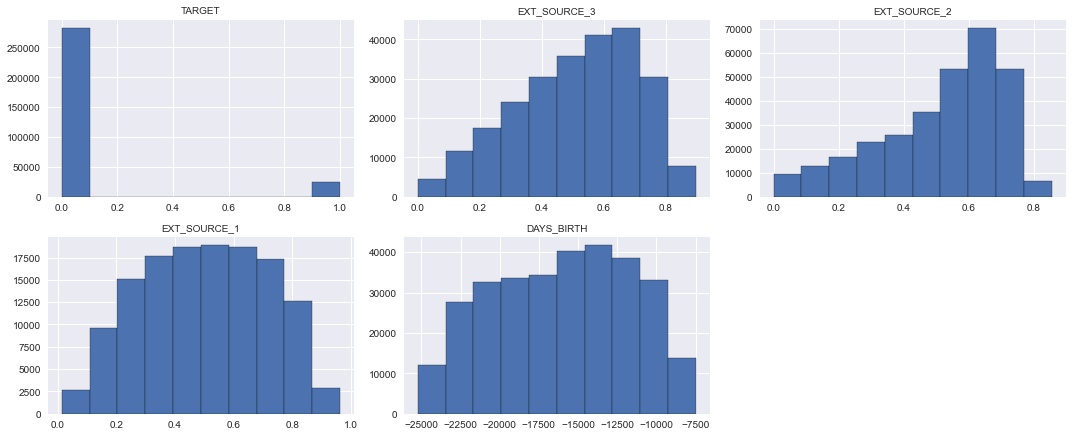

In [284]:
plot_correl_abs_dist(5)

Les distributions EXT_SOURCE suivent une distribution normale et ont des valeurs entre 0 et 1.  

Conversion de la variable Age en valeurs positives et en années :

<function matplotlib.pyplot.show(close=None, block=None)>

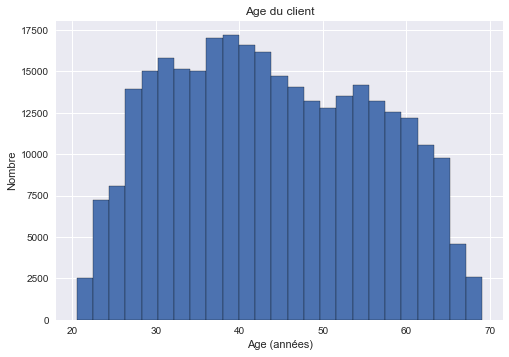

In [285]:
plt.hist(application_train['DAYS_BIRTH'] / -365, edgecolor = 'k', bins = 25)
plt.title('Age du client'); plt.xlabel('Age (années)'); plt.ylabel('Nombre');
plt.show

Les âges sont tous représentés de 20 à 70 ans.  

Visualisation de ces variables avec la TARGET:

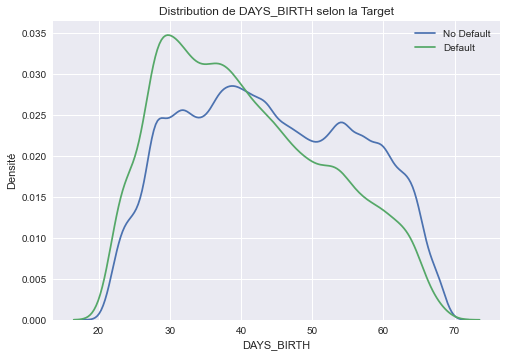

In [286]:
df_age = application_train[['DAYS_BIRTH','TARGET']].copy()
df_age['DAYS_BIRTH'] = abs(df_age['DAYS_BIRTH']/365)
plot_kde_var_traget(df_age, 'DAYS_BIRTH')

Plus l'âge augmente et plus la densité de defauts de paiements diminuent.

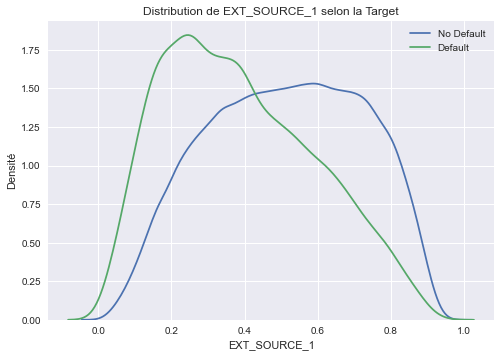

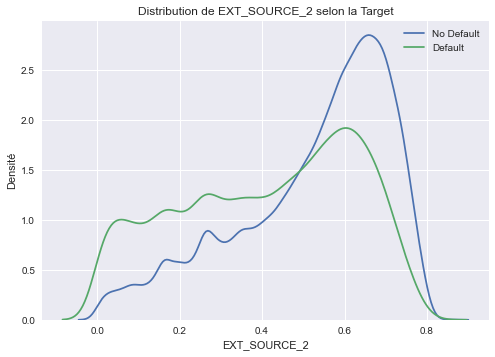

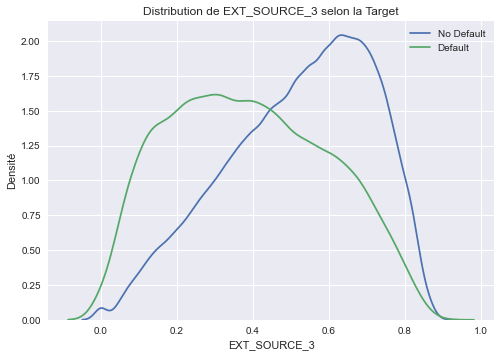

In [287]:
plot_kde_var_traget(application_train, 'EXT_SOURCE_1')
plot_kde_var_traget(application_train, 'EXT_SOURCE_2')
plot_kde_var_traget(application_train, 'EXT_SOURCE_3')

La variable où le paiement et le défaut de paiement sont les plus différenciés est EXT_SOURCE_3.  
Cette variable a un impact sur le fait que le prêt est remboursé ou non.

#### Visualisation de variables catégoriques

In [288]:
def cat_features_plot():

    df = application_train.copy()
    df['TARGET'].replace(0, "No Default", inplace=True)
    df['TARGET'].replace(1, "Default", inplace=True)

    #plt.figure(figsize=(30, 70))
    categorical_col = object_cols(df)
    plot_x = int(len(categorical_col)/2)
    fig, ax = plt.subplots(plot_x, 2, figsize=(20, 50))

    num = 0
    for i in range(0, plot_x):
        for j in range(0,2):
            tst = sns.countplot(x=categorical_col[num],
                               data=df, hue='TARGET', ax=ax[i][j])
            tst.set_title(f"Distribution de la variable {categorical_col[num]}")
            tst.set_xticklabels(tst.get_xticklabels(), rotation=90)
            plt.subplots_adjust(left=None, bottom=None, right=None,
                        top=None, wspace=None, hspace=0.45)
            num = num + 1
            plt.tight_layout()

Visualisation des variables catégoriques de application_train selon la TARGET:

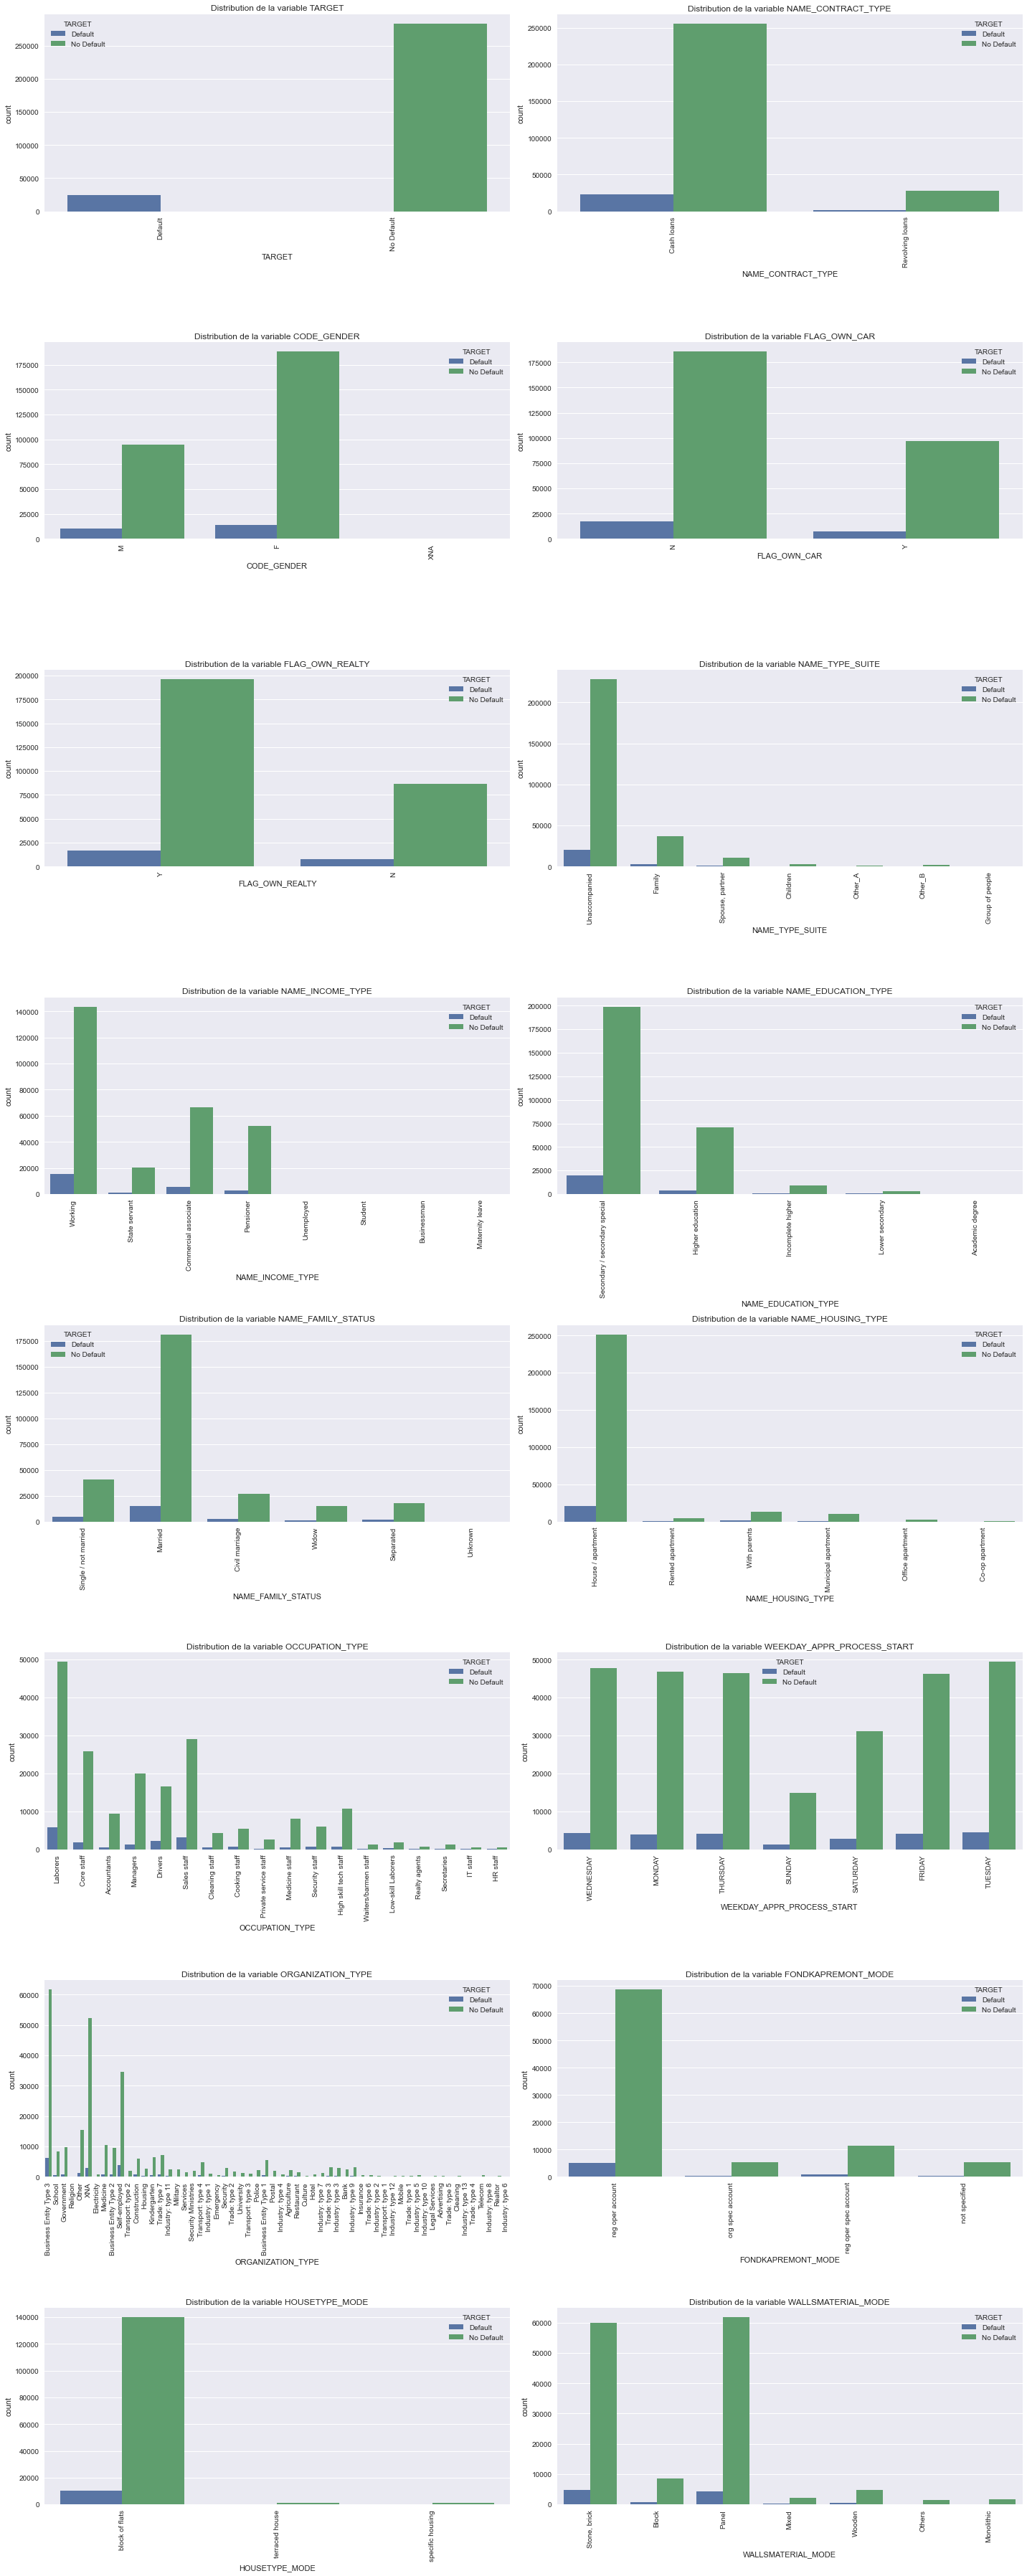

In [289]:
cat_features_plot()

Pour plusieurs variables, le défaut de paiement est différencié selon les catégories:  
occupation_type, organization_type etc...  
Certaines variables sont plus significatives sur le risque de défaut de paiement.

### 3.7 - Conclusion de l'analyse exploratoire <a class="anchor" id="section_3_7"></a>


La variable TARGET est désiquilibrée (imbalanced) ce qui sera à prendre en compte pour la modélisation.  
Des valeurs aberrantes sont à traiter (variables days) : elles seront remplacées par des valeurs nulles.  
Les datasets contiennent des valeurs manquantes qui seront imputées.  
Deux colonnes contenant plus de 99% de valeurs manquantes peuvent être supprimées.  
Les datasets contiennent des variables catégoriques qui seront à transformer.  
Le jeu de données est dispersé dans plusieurs fichiers qui seront à merger.



## 4 - Préparation du jeu de données <a class="anchor" id="chapter4"></a>

Suite à l'analyse exploratoire :  
Remplacement des valeurs aberrantes par nan  
Encodage des variables catégoriques  
Suppression des colonnes (presque) vides  
Aggrégation et merge des datasets  

L'imputation et la normalisation seront faits lors de la modélisation pour éviter les fuites de données.


### 4.1 - Nettoyage et préparation <a class="anchor" id="section_4_1"></a>

In [290]:
import gc
from sklearn.preprocessing import LabelEncoder

def cat_encode(df):

    list_to_label_encode = [col for col in df if df[col].dtype == 'object' and len(list(df[col].unique())) <= 2]
    list_to_dummies = [col for col in df if df[col].dtype == 'object' and len(list(df[col].unique())) > 2]
    le = LabelEncoder()

    for col in list_to_label_encode:
        le.fit(df[col])
        df[col] = le.transform(df[col])
            
    df = pd.get_dummies(df,list_to_dummies)
    
    return df

def aggregate(df,key_to_drop,group_key,prefix):
    grp = df.drop([key_to_drop], axis = 1).groupby(by=[group_key]).mean().reset_index()
    grp.columns = [prefix + '_' + column if column != group_key else column for column in grp.columns]
    return grp

def aggregate_bureau(df,group_key,prefix):
    grp = df.groupby(by=[group_key]).mean().reset_index()
    grp.columns = [prefix + '_' + column if column != group_key else column for column in grp.columns]
    return grp

def remove_outliers_in_days_vars():
    remove_outliers_in_days_var_df(application_train)
    remove_outliers_in_days_var_df(bureau)
    remove_outliers_in_days_var_df(previous_application)
    remove_outliers_in_days_var_df(credit_card)
    remove_outliers_in_days_var_df(insta_payments)
    remove_outliers_in_days_var_df(pos_cash)

def remove_outliers_in_days_vars_df(df):
    for col in np.concatenate((integer_cols(df),float_cols(df))):
        if col.split("_")[0] == 'DAYS':
            mask = df[col]>100*365
            #df[mask][col]= np.nan
            df.loc[mask,col] = np.nan
            df[col + '_ERROR'] = mask            
    return df




In [291]:
data_path = "./data/"
application_train = pd.read_csv(data_path + "application_train.csv", low_memory=False)
bureau = pd.read_csv(data_path + 'bureau.csv', low_memory=False)
bureau_balance = pd.read_csv(data_path + 'bureau_balance.csv', low_memory=False)
previous_application = pd.read_csv(data_path + 'previous_application.csv', low_memory=False)
credit_card = pd.read_csv(data_path + 'credit_card_balance.csv', low_memory=False)
insta_payments = pd.read_csv(data_path + 'installments_payments.csv', low_memory=False)
pos_cash = pd.read_csv(data_path + 'POS_CASH_balance.csv', low_memory=False)


In [292]:

# data preparation : remove outliers, encode categorical datas, aggregate childs datasets, drop empty columns

application_train = remove_outliers_in_days_vars_df(application_train)
application_train = cat_encode(application_train)

bureau_balance = remove_outliers_in_days_vars_df(bureau_balance)
bureau_balance = cat_encode(bureau_balance)
bureau_balance = aggregate_bureau(bureau_balance,'SK_ID_BUREAU','BB')

bureau_merge = bureau.merge(bureau_balance, on='SK_ID_BUREAU', how='left')
bureau_merge = remove_outliers_in_days_vars_df(bureau_merge)
bureau_merge = cat_encode(bureau_merge)
bureau_merge = aggregate(bureau_merge,'SK_ID_BUREAU','SK_ID_CURR','BUREAU')

previous_application.drop(columns=['RATE_INTEREST_PRIVILEGED', 'RATE_INTEREST_PRIMARY'])
previous_application = remove_outliers_in_days_vars_df(previous_application)
previous_application = cat_encode(previous_application)
previous_application = aggregate(previous_application,'SK_ID_PREV','SK_ID_CURR','PREV')

credit_card = remove_outliers_in_days_vars_df(credit_card)
credit_card = cat_encode(credit_card)
credit_card = aggregate(credit_card,'SK_ID_PREV','SK_ID_CURR','PREV_CCB')

insta_payments = remove_outliers_in_days_vars_df(insta_payments)
insta_payments = cat_encode(insta_payments)
insta_payments = aggregate(insta_payments,'SK_ID_PREV','SK_ID_CURR','PREV_IP')

pos_cash = remove_outliers_in_days_vars_df(pos_cash)
pos_cash = cat_encode(pos_cash)
pos_cash = aggregate(pos_cash,'SK_ID_PREV','SK_ID_CURR','PREV_PCB')

print('data preparation done')

data preparation done


### 4.2 - Merges <a class="anchor" id="section_4_2"></a>

In [293]:
df_all = application_train.merge(previous_application, on='SK_ID_CURR', how='left')
del application_train
del previous_application
gc.collect()

65420

In [294]:
df_all = df_all.merge(bureau_merge, on='SK_ID_CURR', how='left')
del bureau_merge
gc.collect()

20

In [295]:
df_all = df_all.merge(credit_card, on='SK_ID_CURR', how='left')
del credit_card
gc.collect()

20

In [296]:
df_all = df_all.merge(insta_payments, on='SK_ID_CURR', how='left')
del insta_payments
gc.collect()

20

In [297]:
df_all = df_all.merge(pos_cash, on='SK_ID_CURR', how='left')
del pos_cash
gc.collect()

20

### 4.3 - Sauvegarde <a class="anchor" id="section_4_3"></a>

In [298]:
df_all.shape

(307511, 512)

In [299]:
#df_all.to_csv(data_path + "clean_merge.csv", index=False)
#del df_all
#gc.collect()


## 5 - Modélisation <a class="anchor" id="chapter5"></a>

### 5.1 - Split du jeu de données <a class="anchor" id="section_5_1"></a>

In [300]:
#import numpy as np
#import pandas as pd
#data_path = "./data/"
#df_all = pd.read_csv(data_path + "clean_merge.csv", low_memory=False)


Création d'un de d'entrainement et d'un jeu de test.  

Pour prendre en compte le déséquilibre de la TARGET, le split est stratifié selon la TARGET.

In [301]:
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(df_all, test_size=0.33, stratify=df_all['TARGET'])


Contrôle de la répartition de la TARGET dans le train set et le test set :

In [302]:

df_all_0 = (df_all['TARGET'].value_counts()[0] / df_all.shape[0])*100
df_all_1 = (df_all['TARGET'].value_counts()[1] / df_all.shape[0])*100

df_train_0 = (train_set['TARGET'].value_counts()[0] / train_set.shape[0])*100
df_train_1 = (train_set['TARGET'].value_counts()[1] / train_set.shape[0])*100

df_test_0 = (test_set['TARGET'].value_counts()[0] / test_set.shape[0])*100
df_test_1 = (test_set['TARGET'].value_counts()[1] / test_set.shape[0])*100


print('\n')
print(f'df_all target 0     : {df_all_0}%')
print(f'df_all target 1     : {df_all_1}%')
print('\n')
print(f'train_set target 0  : {df_train_0}%')
print(f'train_set target 1  : {df_train_1}%')
print('\n')
print(f'test_set target 0   : {df_test_0}%')
print(f'test_set target 1   : {df_test_1}%')




df_all target 0     : 91.92711805431351%
df_all target 1     : 8.072881945686495%


train_set target 0  : 91.92698221635473%
train_set target 1  : 8.073017783645259%


test_set target 0   : 91.92739384503199%
test_set target 1   : 8.072606154968023%


La répartition est bien respectée.

Pour effectuer la phase de sélection de modèles,  
afin de ne pas avoir un jeu trop gros selon les ressources de la machine utilisée,  
et afin d'avoir un jeu assez grand pour l'entrainement,  
création d'un échantillon du train set de 10% (environ 20000 lignes)  

In [303]:
_, train_set_sample = train_test_split(train_set, test_size=0.1, stratify=train_set['TARGET'])

train_set_sample_0 = (train_set_sample['TARGET'].value_counts()[0] / train_set_sample.shape[0])*100
train_set_sample_1 = (train_set_sample['TARGET'].value_counts()[1] / train_set_sample.shape[0])*100

print('\n')
print(f'dimensions de train_set_sample : {train_set_sample.shape}')
print(f'train_set_sample target 0      : {train_set_sample_0}%')
print(f'df_train_set_sample target 1   : {train_set_sample_1}%')




dimensions de train_set_sample : (20604, 512)
train_set_sample target 0      : 91.92875169869929%
df_train_set_sample target 1   : 8.071248301300718%


Séparation des 'features' et de la target (X_train et y_train)

In [304]:
X_train = train_set_sample.loc[:, train_set_sample.columns != 'TARGET']
y_train = train_set_sample.loc[:, train_set_sample.columns == 'TARGET']

In [305]:
X_train.shape

(20604, 511)

In [306]:
y_train.shape

(20604, 1)

### 5.2 - Comparaison de modèles <a class="anchor" id="section_5_2"></a>

### baseline

In [307]:
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline

imputer = SimpleImputer(missing_values=np.nan, strategy='median')

preprocessor = Pipeline([('impute',imputer)])
params_lr = {'clf__C': np.logspace(-3, 3, 7) , 'clf__penalty':['l1','l2'] }
pipeline = Pipeline([('preprocessor',preprocessor),('clf',LogisticRegression())])

gs = RandomizedSearchCV(pipeline, param_distributions=params_lr, n_jobs = -1,scoring='roc_auc', cv=3)
gs.fit(X_train,y_train.values.ravel())
gs.best_score_


0.651050444915708

### iteration 1 : test de différents algorithmes sans preprocessing

In [308]:

from sklearn.ensemble import RandomForestClassifier
from sklearn import svm
from sklearn.svm import LinearSVC
    
classifiers_list = ['LogisticRegression', 'RandomForestClassifier','SVM']

params_rf = { 
    'clf__n_estimators': [200, 500],
    'clf__max_features': ['auto', 'sqrt', 'log2'],
    'clf__max_depth' : [4,5,6,7,8],
    'clf__criterion' :['gini', 'entropy']
}

params_svm = {
    'clf__C': np.logspace(-2, 3, 6)}

tested_models={}
best_params={}
df_resultat = pd.DataFrame({'classifier': classifiers_list})

def modelling_v1(preprocessor,clf,params,cv, X, y):
    pipeline = Pipeline([('preprocessor',preprocessor),('clf',clf)])
    gs = RandomizedSearchCV(pipeline, param_distributions=params, n_jobs = -1, scoring='roc_auc', cv=cv)
    gs.fit(X,y.values.ravel())
    return gs

def add_results(result,df_resultat,tested_models,best_params,iteration,clf_name):
    df_resultat.loc[df_resultat['classifier'] == clf_name, iteration] = result.best_score_
    tested_models[clf_name] = {iteration : result.best_estimator_}
    best_params[clf_name] = {iteration : result.best_params_}




In [309]:
iteration = 'iteration1'

#ajout de la baseline dans le tableau des résultats
add_results(gs,df_resultat,tested_models,best_params,iteration,'LogisticRegression')

#autres algorithmes

cv = 3

result = modelling_v1(preprocessor,RandomForestClassifier(),params_rf,cv,X_train,y_train)
add_results(result,df_resultat,tested_models,best_params,iteration,'RandomForestClassifier')

result = modelling_v1(preprocessor,LinearSVC(), params_svm,cv,X_train,y_train)
add_results(result,df_resultat,tested_models,best_params,iteration,'SVM')


In [310]:
df_resultat

,classifier,iteration1
0,LogisticRegression,0.651050
1,RandomForestClassifier,0.729515
2,SVM,0.608164


### iteration 2 : scaling

In [311]:

from sklearn.preprocessing import MinMaxScaler,StandardScaler

iteration = 'iteration2'
scaler = MinMaxScaler(feature_range = (0, 1))
preprocessor = Pipeline([('impute',imputer),('scale',scaler)])

result = modelling_v1(preprocessor,LogisticRegression(),params_lr, cv,X_train,y_train)
add_results(result,df_resultat,tested_models,best_params,iteration,'LogisticRegression')

result = modelling_v1(preprocessor,RandomForestClassifier(),params_rf, cv,X_train,y_train)
add_results(result,df_resultat,tested_models,best_params,iteration,'RandomForestClassifier')

result = modelling_v1(preprocessor,LinearSVC(), params_svm, cv,X_train,y_train)
add_results(result,df_resultat,tested_models,best_params,iteration,'SVM')



In [312]:
df_resultat

,classifier,iteration1,iteration2
0,LogisticRegression,0.651050,0.735645
1,RandomForestClassifier,0.729515,0.728854
2,SVM,0.608164,0.735238


### iteration 3 : stratified cross validation

In [313]:
from sklearn.model_selection import StratifiedKFold

iteration = 'iteration3'
cv = StratifiedKFold(n_splits=3)

result = modelling_v1(preprocessor,LogisticRegression(),params_lr, cv,X_train,y_train)
add_results(result,df_resultat,tested_models,best_params,iteration,'LogisticRegression')

result = modelling_v1(preprocessor,RandomForestClassifier(),params_rf, cv,X_train,y_train)
add_results(result,df_resultat,tested_models,best_params,iteration,'RandomForestClassifier')

result = modelling_v1(preprocessor,LinearSVC(), params_svm, cv,X_train,y_train)
add_results(result,df_resultat,tested_models,best_params,iteration,'SVM')



In [314]:
df_resultat

,classifier,iteration1,iteration2,iteration3
0,LogisticRegression,0.651050,0.735645,0.735645
1,RandomForestClassifier,0.729515,0.728854,0.728978
2,SVM,0.608164,0.735238,0.735238


### iteration 4 : class_weight balanced

In [315]:

iteration = 'iteration4'

result = modelling_v1(preprocessor,LogisticRegression(class_weight = 'balanced'),params_lr, cv,X_train,y_train)
add_results(result,df_resultat,tested_models,best_params,iteration,'LogisticRegression')

result = modelling_v1(preprocessor,RandomForestClassifier(class_weight = 'balanced'),params_rf, cv,X_train,y_train)
add_results(result,df_resultat,tested_models,best_params,iteration,'RandomForestClassifier')

result = modelling_v1(preprocessor,LinearSVC(class_weight = 'balanced'), params_svm, cv,X_train,y_train)
add_results(result,df_resultat,tested_models,best_params,iteration,'SVM')




In [316]:
df_resultat

,classifier,iteration1,iteration2,iteration3,iteration4
0,LogisticRegression,0.651050,0.735645,0.735645,0.731619
1,RandomForestClassifier,0.729515,0.728854,0.728978,0.715114
2,SVM,0.608164,0.735238,0.735238,0.735001


### iteration 5 : data sampling

In [317]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import make_pipeline as make_pipeline_with_sampler

def modelling_v2(pipeline,params,cv,X,y):
    gs = RandomizedSearchCV(pipeline, param_distributions=params, n_jobs = -1, scoring='roc_auc', cv=cv)
    gs.fit(X,y.values.ravel())
    return gs

params_lr_resample = {
    'logisticregression__C': np.logspace(-3, 3, 7) , 
    'logisticregression__penalty':['l1','l2'] }

params_rf_resample = { 
    'randomforestclassifier__n_estimators': [200, 500],
    'randomforestclassifier__max_features': ['auto', 'sqrt', 'log2'],
    'randomforestclassifier__max_depth' : [4,5,6,7,8],
    'randomforestclassifier__criterion' :['gini', 'entropy']}

params_svm_resample = {
    'linearsvc__C': np.logspace(-2, 3, 6)}


In [318]:

iteration = 'iteration5'

over = SMOTE(sampling_strategy=0.1)
under = RandomUnderSampler(sampling_strategy=0.5)

clf = LogisticRegression(class_weight = 'balanced')
pipeline = make_pipeline_with_sampler(imputer,scaler,over,under,clf)
result = modelling_v2(pipeline,params_lr_resample, cv, X_train, y_train)
add_results(result,df_resultat,tested_models,best_params,iteration,'LogisticRegression')

clf = RandomForestClassifier(class_weight = 'balanced')
pipeline = make_pipeline_with_sampler(imputer,scaler,over,under,clf)
result = modelling_v2(pipeline,params_rf_resample, cv, X_train, y_train)
add_results(result,df_resultat,tested_models,best_params,iteration,'RandomForestClassifier')

clf = LinearSVC(class_weight = 'balanced')
pipeline = make_pipeline_with_sampler(imputer,scaler,over,under,clf)
result = modelling_v2(pipeline,params_svm_resample, cv, X_train, y_train)
add_results(result,df_resultat,tested_models,best_params,iteration,'SVM')



In [319]:
df_resultat

,classifier,iteration1,iteration2,iteration3,iteration4,iteration5
0,LogisticRegression,0.651050,0.735645,0.735645,0.731619,0.724593
1,RandomForestClassifier,0.729515,0.728854,0.728978,0.715114,0.721146
2,SVM,0.608164,0.735238,0.735238,0.735001,0.730251


### iteration 6 : feature engineering : nouvelles variables 

In [320]:
X_train_copy = X_train.copy()
X_train['DAYS_EMPLOYED_PERC'] = X_train['DAYS_EMPLOYED'] / X_train['DAYS_BIRTH']
X_train['INCOME_CREDIT_PERC'] = X_train['AMT_INCOME_TOTAL'] / X_train['AMT_CREDIT']
X_train['INCOME_PER_PERSON'] = X_train['AMT_INCOME_TOTAL'] / X_train['CNT_FAM_MEMBERS']
X_train['ANNUITY_INCOME_PERC'] = X_train['AMT_ANNUITY'] / X_train['AMT_INCOME_TOTAL']
X_train['PAYMENT_RATE'] = X_train['AMT_ANNUITY'] / X_train['AMT_CREDIT']


In [323]:
iteration = 'iteration6'
cv = StratifiedKFold(n_splits=3)

clf = LogisticRegression(class_weight = 'balanced')
pipeline = make_pipeline_with_sampler(imputer,scaler,over,under,clf)
result = modelling_v2(pipeline,params_lr_resample, cv, X_train, y_train)
add_results(result,df_resultat,tested_models,best_params,iteration,'LogisticRegression')

clf = RandomForestClassifier(class_weight = 'balanced')
pipeline = make_pipeline_with_sampler(imputer,scaler,over,under,clf)
result = modelling_v2(pipeline,params_rf_resample, cv, X_train, y_train)
add_results(result,df_resultat,tested_models,best_params,iteration,'RandomForestClassifier')

clf = LinearSVC(class_weight = 'balanced')
pipeline = make_pipeline_with_sampler(imputer,scaler,over,under,clf)
result = modelling_v2(pipeline,params_svm_resample, cv, X_train, y_train)
add_results(result,df_resultat,tested_models,best_params,iteration,'SVM')


In [324]:
df_resultat

,classifier,iteration1,iteration2,iteration3,iteration4,iteration5,iteration6
0,LogisticRegression,0.651050,0.735645,0.735645,0.731619,0.724593,0.717017
1,RandomForestClassifier,0.729515,0.728854,0.728978,0.715114,0.721146,0.723150
2,SVM,0.608164,0.735238,0.735238,0.735001,0.730251,0.731208


### 5.3 - Evaluation du modèle sélectionné sur le jeu de test <a class="anchor" id="section_5_3"></a>

Comme pour le train set, échantillon de 10% du test set

In [113]:
_, test_set_sample = train_test_split(test_set, test_size=0.1, stratify=test_set['TARGET'])
X_test = test_set_sample.loc[:, test_set_sample.columns != 'TARGET']
y_test = test_set_sample.loc[:, test_set_sample.columns == 'TARGET']
X_test.shape

(10148, 502)

In [114]:
X_test_copy = X_test.copy()
X_test['DAYS_EMPLOYED_PERC'] = X_test['DAYS_EMPLOYED'] / X_test['DAYS_BIRTH']
X_test['INCOME_CREDIT_PERC'] = X_test['AMT_INCOME_TOTAL'] / X_test['AMT_CREDIT']
X_test['INCOME_PER_PERSON'] = X_test['AMT_INCOME_TOTAL'] / X_test['CNT_FAM_MEMBERS']
X_test['ANNUITY_INCOME_PERC'] = X_test['AMT_ANNUITY'] / X_test['AMT_INCOME_TOTAL']
X_test['PAYMENT_RATE'] = X_test['AMT_ANNUITY'] / X_test['AMT_CREDIT']

In [189]:
pipeline = tested_models['RandomForestClassifier']['iteration6']


In [190]:
from sklearn.metrics import roc_curve, auc


In [191]:
y_prob = pipeline.predict_proba(X_test)[:,1] 

false_positive_rate, true_positive_rate, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(false_positive_rate, true_positive_rate)
print(roc_auc7)

0.7399641722720295


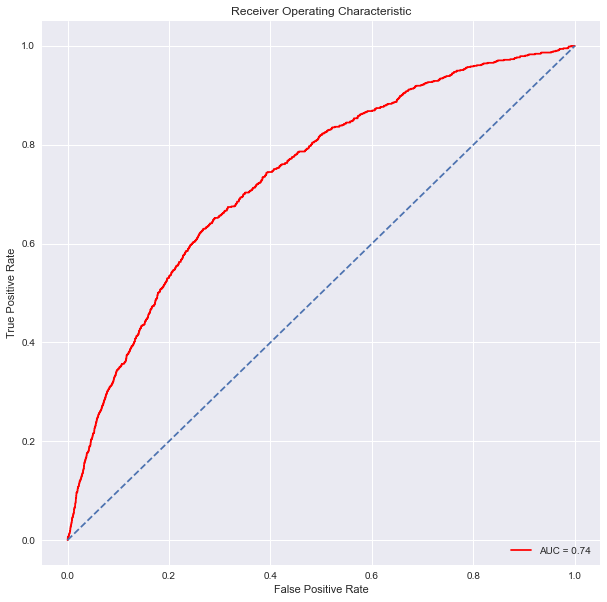

In [192]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,10))
plt.title('Receiver Operating Characteristic')
plt.plot(false_positive_rate,true_positive_rate, color='red',label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],linestyle='--')
plt.axis('tight')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

In [193]:
j_stat = true_positive_rate - false_positive_rate
index_for_best_threshold = np.argmax(j_stat)
thresholds[index_for_best_threshold]


0.4911681664153319

In [194]:

from sklearn.metrics import recall_score, precision_score,f1_score
from sklearn.metrics import confusion_matrix

def calculate_metrics(y_prob, y_test, thresholds):
    
    df_metrics = pd.DataFrame({'threshold': thresholds})

    for threshold in thresholds:

        y_predict = np.where(y_prob > threshold, 1, 0) 

        cm = confusion_matrix(y_test, y_predict)
        recall = recall_score(y_test, y_predict)
        precision = precision_score(y_test, y_predict)
        f1score = f1_score(y_test, y_predict)

        df_metrics.loc[df_metrics['threshold'] == threshold, 'fn'] = cm[1,0]
        df_metrics.loc[df_metrics['threshold'] == threshold, 'fp'] = cm[0,1]
        df_metrics.loc[df_metrics['threshold'] == threshold, 'tp'] = cm[1,1]
        df_metrics.loc[df_metrics['threshold'] == threshold, 'tn'] = cm[0,0]

        df_metrics.loc[df_metrics['threshold'] == threshold, 'recall'] = recall
        df_metrics.loc[df_metrics['threshold'] == threshold, 'precision'] = precision
        df_metrics.loc[df_metrics['threshold'] == threshold, 'f1_score'] = f1score

    return df_metrics

In [195]:
thresholds_test = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
df_metrics = calculate_metrics(y_prob, y_test, thresholds_test)
df_metrics

,threshold,fn,fp,tp,tn,recall,precision,f1_score
0,0.1,0.0,9329.0,819.0,0.0,1.000000,0.080706,0.149357
1,0.2,0.0,9329.0,819.0,0.0,1.000000,0.080706,0.149357
2,0.3,5.0,9068.0,814.0,261.0,0.993895,0.082372,0.152135
3,0.4,75.0,6231.0,744.0,3098.0,0.908425,0.106667,0.190916
4,0.5,336.0,2228.0,483.0,7101.0,0.589744,0.178163,0.273654
5,0.6,683.0,335.0,136.0,8994.0,0.166056,0.288747,0.210853
6,0.7,815.0,5.0,4.0,9324.0,0.004884,0.444444,0.009662
7,0.8,819.0,0.0,0.0,9329.0,0.000000,0.000000,0.000000
8,0.9,819.0,0.0,0.0,9329.0,0.000000,0.000000,0.000000


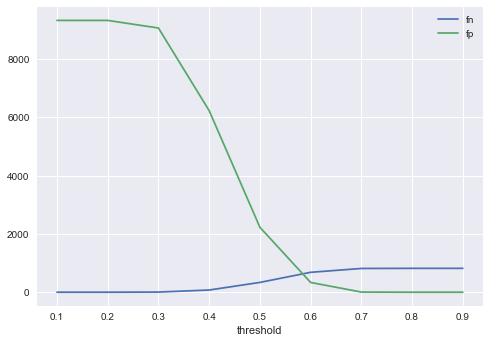

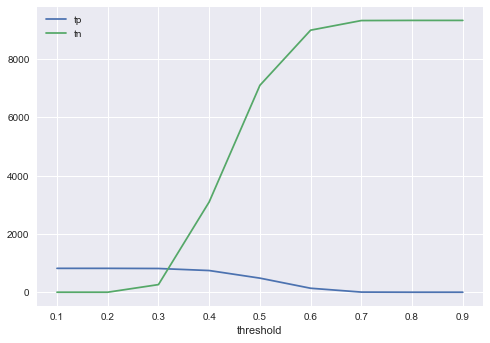

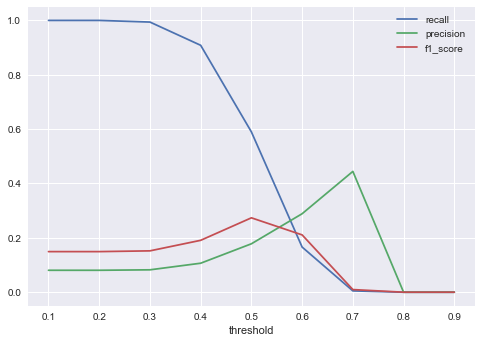

In [196]:
df_metrics.plot(x="threshold",y=["fn","fp"])
df_metrics.plot(x="threshold",y=["tp","tn"])
df_metrics.plot(x="threshold",y=["recall","precision","f1_score"])
plt.show()

### 5.4 - Importance des variables <a class="anchor" id="section_5_4"></a>

In [197]:
domain_features_names = list(np.array(X_train.columns))
feature_importance_values_domain = pipeline.steps[4][1].feature_importances_
feature_importances_domain = pd.DataFrame({'feature': domain_features_names, 'importance': feature_importance_values_domain})

In [198]:
def plot_feature_importances(df):
    
    # Sort features according to importance
    df = df.sort_values('importance', ascending = False).reset_index()
    
    # Normalize the feature importances to add up to one
    df['importance_normalized'] = df['importance'] / df['importance'].sum()

    # Make a horizontal bar chart of feature importances
    plt.figure(figsize = (10, 6))
    ax = plt.subplot()
    
    # Need to reverse the index to plot most important on top
    ax.barh(list(reversed(list(df.index[:15]))), 
            df['importance_normalized'].head(15), 
            align = 'center', edgecolor = 'k')
    
    # Set the yticks and labels
    ax.set_yticks(list(reversed(list(df.index[:15]))))
    ax.set_yticklabels(df['feature'].head(15))
    
    # Plot labeling
    plt.xlabel('Normalized Importance'); plt.title('Feature Importances')
    plt.show()
    
    return df

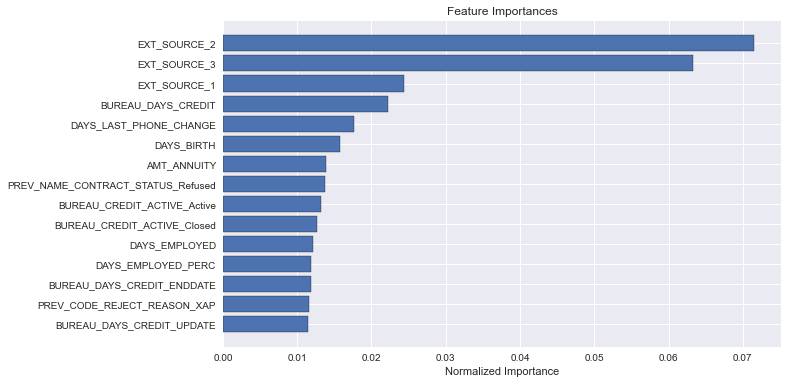

In [199]:
feature_importances_sorted = plot_feature_importances(feature_importances_domain)


## 6 - Conclusion <a class="anchor" id="chapter6"></a>

Ce projet aboutit à un modèle permettant de faire des prédictions de paiement à partir du jeu de données Home Credit.  
Pour évaluer les modèles, la métrique roc auc a été utilisée.  
De nombreuses modélisations ont été effectuées à partir de ce jeu de données, et le feature engineering permet d'améliorer le score roc auc, 
notamment la création de variables ou encore la feature selection.  
D'autres algorithmes peuvent être testés comme par exemple XGBoost ou LightGBM.
